# KartuVerbs 2.2: Random Forest-Based Data Completion

This notebook implements the machine-learning component of the **KartuVerbs** infrastructure for Georgian verb lemmatization.

## Objective

The KartuVerbs source data contain detailed morphological information for Georgian inflected verb forms. For a substantial subset of the resource, the corresponding verbal noun is missing.

The objective of this notebook is to reconstruct missing verbal-noun values using a **Random Forest classifier**.

The notebook reproduces the principal machine-learning experiments reported in the accompanying article:

**"Enhancing KartuVerbs with Random Forest-Based Data Completion and Expert Crowdsourcing for Georgian Verb Lemmatization"**

The workflow includes:

1. loading and validating the source data;
2. encoding categorical and Georgian textual features;
3. encoding verbal nouns as classification targets;
4. standard 80/20 row-level evaluation;
5. out-of-bag (OOB) evaluation;
6. five-fold KFold cross-validation;
7. GroupShuffleSplit evaluation using complete paradigm groups;
8. five-fold GroupKFold evaluation;
9. Random Forest feature-importance analysis;
10. ablation analysis of identifier-related features;
11. training a final model on all available labelled data;
12. reconstructing missing verbal-noun values.

## Reproducibility

All result-dependent numerical summaries in this notebook are generated directly from values calculated during execution. They are not manually copied into the explanatory text.

For reproducibility, the notebook should be executed from beginning to end using **Restart Kernel and Run All Cells**.

The distinction between row-level and group-based evaluation is important. Row-level evaluation measures reconstruction when related lexical and paradigmatic structures may already be represented in the training data. Group-based evaluation keeps complete `raw_sub_id` paradigm groups separate and therefore evaluates the more difficult problem of prediction for previously unseen verb paradigms. Different paradigms sharing the same broader common-root identifier (`id`) may nevertheless occur in both training and test partitions.

Machine-learning predictions are not treated as definitive linguistic ground truth. They are additionally compared with the Georgian National Corpus, while a new expert-validation task is being prepared in the Headwork crowdsourcing workflow.

## Input data

The notebook uses two semicolon-delimited source files.

### Labelled data

`data_vn+withnotfullcroots`

This dataset contains records for which the verbal noun (`vn`) is known and
can therefore be used for supervised machine learning.

### Data with missing verbal nouns

`data_vn-`

This dataset contains records for which the verbal noun must be reconstructed.

### Source fields

| Field | Description |
|---|---|
| `form` | Inflected Georgian verb form |
| `tense_in_paradigm` | Tense |
| `person` | Grammatical person |
| `number` | Singular or plural |
| `preverb` | Preverb |
| `pre2` | Preradical |
| `root` | Verb root |
| `sf2` | Stem formant |
| `caus_sf` | Causative stem formant |
| `ending` | Ending |
| `tsch_class` | Tschenkeli class |
| `morph_type` | Morphological type |
| `id` | Identifier linking the form to its common-root group |
| `sub_id` | Identifier linking the form to its verb paradigm |
| `vn` | Verbal noun; present only in the labelled dataset |

The source data originate from the Georgian verb database developed within
the CLARINO/INESS infrastructure.

In [1]:
from pathlib import Path
import json
import platform
import sys

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn

import gc
from time import perf_counter

NOTEBOOK_START_TIME = perf_counter()

from IPython.display import Markdown, display

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
)
from sklearn.model_selection import (
    GroupKFold,
    GroupShuffleSplit,
    KFold,
    train_test_split,
)

%config InlineBackend.figure_formats = ['svg']
%matplotlib inline


# --------------------------------------------------
# Reproducibility configuration
# --------------------------------------------------

RANDOM_STATE = 101
N_ESTIMATORS = 100

LABELED_DATA_PATH = Path("data_vn+withnotfullcroots")
MISSING_DATA_PATH = Path("data_vn-")

RESULTS_DIR = Path("results")
FIGURES_DIR = Path("figures")
MODELS_DIR = Path("models")

RESULTS_DIR.mkdir(exist_ok=True)
FIGURES_DIR.mkdir(exist_ok=True)
MODELS_DIR.mkdir(exist_ok=True)


# --------------------------------------------------
# Formatting helpers for dynamic Markdown
# --------------------------------------------------

def pct(value, digits=2):
    """Format a proportion as a percentage."""
    return f"{float(value) * 100:.{digits}f}%"


def pp(value, digits=2):
    """Format a proportion as percentage points."""
    return f"{float(value) * 100:.{digits}f} pp"


def nfmt(value):
    """Format an integer with thousands separators."""
    return f"{int(value):,}"


# --------------------------------------------------
# Software environment
# --------------------------------------------------

print("Python:", sys.version.split()[0])
print("Platform:", platform.platform())
print("pandas:", pd.__version__)
print("NumPy:", np.__version__)
print("scikit-learn:", sklearn.__version__)

Python: 3.12.13
Platform: Linux-7.0.0-29-generic-x86_64-with-glibc2.43
pandas: 3.0.3
NumPy: 2.4.6
scikit-learn: 1.9.0


## 1. Load the labelled data

The labelled dataset is used for model training and evaluation.

Before any transformation is performed, the notebook checks that all
required source columns are present. The original `sub_id` values are
preserved because they are later used as grouping variables in
GroupShuffleSplit and GroupKFold evaluation.

In [2]:
REQUIRED_FEATURE_COLUMNS = [
    "form",
    "tense_in_paradigm",
    "person",
    "number",
    "preverb",
    "pre2",
    "root",
    "sf2",
    "caus_sf",
    "ending",
    "tsch_class",
    "morph_type",
    "sub_id",
    "id",
]

REQUIRED_LABELED_COLUMNS = REQUIRED_FEATURE_COLUMNS + ["vn"]


kv_raw = pd.read_csv(
    LABELED_DATA_PATH,
    sep=";"
)


missing_columns = [
    column
    for column in REQUIRED_LABELED_COLUMNS
    if column not in kv_raw.columns
]

if missing_columns:
    raise ValueError(
        f"Required columns are missing from the labelled dataset: "
        f"{missing_columns}"
    )


print("Labelled dataset shape:", kv_raw.shape)
print("Number of rows:", len(kv_raw))
print("Number of columns:", len(kv_raw.columns))

display(kv_raw.head())

Labelled dataset shape: (294665, 15)
Number of rows: 294665
Number of columns: 15


,form,tense_in_paradigm,person,number,preverb,pre2,root,sf2,caus_sf,ending,tsch_class,morph_type,sub_id,id,vn
0,ვამხანაგობ,present,1,sg,-,ვ,ამხანაგ,ობ,-,-,MV,active,39-1,39,*ამხანაგობა
1,ჰამხანაგობ,present,2,sg,-,ჰ,ამხანაგ,ობ,-,-,MV,active,39-1,39,*ამხანაგობა
2,ამხანაგობ,present,2,sg,-,-,ამხანაგ,ობ,-,-,MV,active,39-1,39,*ამხანაგობა
3,ჰამხანაგობს,present,3,sg,-,ჰ,ამხანაგ,ობ,-,ს,MV,active,39-1,39,*ამხანაგობა
4,ამხანაგობს,present,3,sg,-,-,ამხანაგ,ობ,-,ს,MV,active,39-1,39,*ამხანაგობა


In [3]:
print("Data types:")
display(
    kv_raw.dtypes
    .rename("dtype")
    .to_frame()
)


# In the source data, "-" is frequently used as a linguistic
# empty/not-applicable marker rather than a pandas NaN value.

dash_counts = pd.Series({
    column: (kv_raw[column].astype(str) == "-").sum()
    for column in kv_raw.columns
})

dash_summary = pd.DataFrame({
    "dash_count": dash_counts,
    "dash_percent": dash_counts / len(kv_raw) * 100,
})

dash_summary = dash_summary[
    dash_summary["dash_count"] > 0
].sort_values(
    "dash_percent",
    ascending=False
)

print("Source fields containing '-' markers:")
display(dash_summary)

Data types:


,dtype
form,str
tense_in_paradigm,str
person,int64
number,str
preverb,str
pre2,str
root,str
sf2,str
caus_sf,str
ending,str


Source fields containing '-' markers:


,dash_count,dash_percent
caus_sf,289959,98.402932
sf2,165428,56.141042
preverb,125287,42.518453
pre2,29913,10.151528
ending,7350,2.494358


## 2. Feature encoding

The Random Forest classifier requires numerical input features. The
KartuVerbs source data contain both categorical values and Georgian strings,
so several deterministic transformations are applied.

### Categorical variables

Tense, number, preverb, stem formant, causative stem formant, Tschenkeli
class, and morphology type are mapped to integer category identifiers.

These integers are **technical category codes only**. Their numerical values
must not be interpreted as linguistic distances or as an ordering of the
linguistic categories.

### Georgian textual features

For `form`, `pre2`, `root`, and `ending`, the implementation uses the custom
numeric representation employed in the KartuVerbs experiments.

For each character, the final byte of its UTF-8 representation is extracted,
and these byte values are summed across the string.

This representation is deterministic but is **not a linguistic distance
measure and is not guaranteed to be one-to-one**: different strings may in
principle produce the same numeric value.

For textual component fields, the source marker `-` is first replaced by the
literal string `"0"` before this encoding is applied.

The same transformations are used for both model training and prediction.

In [4]:
# --------------------------------------------------
# Categorical mappings
# --------------------------------------------------

TENSE_MAP = {
    "present": 1,
    "imperfect": 2,
    "conj-present": 3,
    "future": 4,
    "conditional": 5,
    "conj-future": 6,
    "aorist": 7,
    "optative": 8,
    "perfect": 9,
    "pluperfect": 10,
    "conj-perfect": 11,
}


MORPH_MAP = {
    "-": 0,
    "active": 1,
    "causative": 2,
    "passive": 3,
    "stative-passive": 4,
}


TSCH_MAP = {
    "IV1": 1,
    "IV2": 2,
    "IV3": 3,
    "IV4": 4,
    "KT": 5,
    "MV": 6,
    "P1": 7,
    "P2": 8,
    "P3": 9,
    "RM1": 10,
    "RM2": 11,
    "RM3": 12,
    "RM4": 13,
    "RP1": 14,
    "RP2": 15,
    "RP3": 16,
    "RP4": 17,
    "RP5": 18,
    "RP6": 19,
    "RP7": 20,
    "T1": 21,
    "T2": 22,
    "T3": 23,
    "T4": 24,
    "T5": 25,
    "ZP1": 26,
    "ZP2": 27,
    "ZP3": 28,
}


NUMBER_MAP = {
    "sg": 1,
    "pl": 2,
}


PREVERB_MAP = {
    "-": 0,
    "ა": 1,
    "ამო": 2,
    "აღ": 3,
    "აღმო": 4,
    "გა": 5,
    "გად": 6,
    "გადა": 7,
    "გადმო": 8,
    "გამო": 9,
    "გან": 10,
    "გარდ": 11,
    "გარდა": 12,
    "გარემო": 13,
    "გარსშემო": 14,
    "გარშემო": 15,
    "და": 16,
    "დამო": 17,
    "თანა": 18,
    "იავარ": 19,
    "მი": 20,
    "მიმო": 21,
    "მო": 22,
    "უკუ": 23,
    "შე": 24,
    "შემო": 25,
    "შთა": 26,
    "ჩა": 27,
    "ჩამო": 28,
    "ძალ": 29,
    "წა": 30,
    "წამო": 31,
    "წარ": 32,
    "წარმო": 33,
    "წინა": 34,

    # Additional values occurring in the data with missing verbal nouns
    "გარდმო": 35,
    "ზეწამო": 36,
    "იძულებულ": 37,
    "ნათელ": 38,
    "სრულ": 39,
    "უარ": 40,
    "უგულებელ": 41,
    "უვნებელ": 42,
    "უზრუნველ": 43,
    "უკვდავ": 44,
    "უჩინარ": 45,
    "ღაღად": 46,
    "შეურაცხ": 47,
    "ცხად": 48,
    "ხელ": 49,
    "წინააღ": 50,
}


SF2_MAP = {
    "-": 0,
    "ავ": 1,
    "ამ": 2,
    "ე": 3,
    "ებ": 4,
    "ევ": 5,
    "ვ": 6,
    "ი": 7,
    "მ": 8,
    "ობ": 9,
    "ოფ": 10,
}


CAUS_MAP = {
    "-": 0,
    "ევინ": 1,
    "ინ": 2,
}


CATEGORY_MAPPINGS = {
    "tense_in_paradigm": TENSE_MAP,
    "morph_type": MORPH_MAP,
    "tsch_class": TSCH_MAP,
    "number": NUMBER_MAP,
    "preverb": PREVERB_MAP,
    "sf2": SF2_MAP,
    "caus_sf": CAUS_MAP,
}


MODEL_FEATURES = [
    "formd",
    "tense",
    "person",
    "number",
    "preverb",
    "pre2d",
    "rootd",
    "sf2",
    "caus_sf",
    "endingd",
    "tsch_class",
    "morph_type",
    "sub_id",
    "id",
]


MODEL_DTYPES = {
    "formd": "uint16",
    "tense": "uint8",
    "person": "uint8",
    "number": "uint8",
    "preverb": "uint8",
    "pre2d": "uint16",
    "rootd": "uint16",
    "sf2": "uint8",
    "caus_sf": "uint8",
    "endingd": "uint16",
    "tsch_class": "uint8",
    "morph_type": "uint8",
    "sub_id": "uint16",
    "id": "uint16",
}

In [5]:
def georgian_string_code(value):
    """
    Convert a string to the custom numeric representation used in the
    KartuVerbs experiments.

    For each character, the last byte of its UTF-8 encoding is extracted
    and the byte values are summed.

    This is a technical representation, not a linguistic distance measure.
    """
    text = str(value)

    return sum(
        character.encode("utf-8")[-1]
        for character in text
    )


def validate_known_categories(df, mappings):
    """
    Check that every categorical value in the dataframe is represented
    in the corresponding encoding dictionary.
    """
    for column, mapping in mappings.items():

        observed = set(
            df[column]
            .dropna()
            .astype(str)
            .unique()
        )

        unknown = sorted(
            observed - set(mapping.keys())
        )

        if unknown:
            raise ValueError(
                f"Unknown values in column '{column}': {unknown}"
            )


def preprocess_features(df):
    """
    Convert the original KartuVerbs feature columns into the 14 numerical
    features used by the Random Forest.

    Returns
    -------
    X : pandas.DataFrame
        Numerical model features.

    raw_sub_id : pandas.Series
        Original sub_id values, preserved for group-based evaluation.
    """

    out = df.copy()

    missing_columns = [
        column
        for column in REQUIRED_FEATURE_COLUMNS
        if column not in out.columns
    ]

    if missing_columns:
        raise ValueError(
            f"Required feature columns are missing: {missing_columns}"
        )

    if out[REQUIRED_FEATURE_COLUMNS].isna().any().any():
        raise ValueError(
            "Unexpected pandas NaN values were found in the source "
            "feature columns."
        )

    # Preserve the original paradigm/group identifier.
    raw_sub_id = out["sub_id"].astype("string").copy()

    # Validate categorical values before encoding.
    validate_known_categories(
        out,
        CATEGORY_MAPPINGS
    )

    # Encode categorical values.
    for column, mapping in CATEGORY_MAPPINGS.items():
        out[column] = out[column].map(mapping)

    # Preserve the behaviour of the original implementation:
    # "-" in text-like components becomes literal string "0".
    for column in ["pre2", "root", "ending"]:
        out[column] = (
            out[column]
            .replace("-", "0")
            .astype("string")
        )

    # sub_id has values such as "39-1".
    # The model uses the numeric component after the final hyphen.
    out["sub_id"] = (
        out["sub_id"]
        .astype("string")
        .str.replace(r".*-", "", regex=True)
    )

    out["sub_id"] = pd.to_numeric(
        out["sub_id"],
        errors="raise"
    )

    # Custom string-derived numerical features.
    out["formd"] = out["form"].apply(
        georgian_string_code
    )

    out["pre2d"] = out["pre2"].apply(
        georgian_string_code
    )

    out["rootd"] = out["root"].apply(
        georgian_string_code
    )

    out["endingd"] = out["ending"].apply(
        georgian_string_code
    )

    # Simplify the model feature name.
    out.rename(
        columns={
            "tense_in_paradigm": "tense"
        },
        inplace=True
    )

    X = out.loc[:, MODEL_FEATURES].copy()

    X = X.astype(MODEL_DTYPES)

    return X, raw_sub_id

## 3. Prepare the labelled machine-learning dataset

The verbal noun (`vn`) is the classification target.

Each distinct verbal noun is assigned an integer class identifier. Class
identifiers are assigned in order of first appearance in the labelled
dataset, preserving the behaviour of the original KartuVerbs implementation.

The mapping is retained so that numerical predictions can later be converted
back to Georgian verbal nouns.

The original `sub_id` values are also preserved separately for group-based
evaluation.

In [6]:
# --------------------------------------------------
# Prepare model features
# --------------------------------------------------

X, groups_raw_sub_id = preprocess_features(
    kv_raw
)


# --------------------------------------------------
# Encode the target verbal noun
# --------------------------------------------------

if kv_raw["vn"].isna().any():
    raise ValueError(
        "The labelled dataset contains missing verbal nouns."
    )


target_codes, target_labels = pd.factorize(
    kv_raw["vn"].astype("string"),
    sort=False
)


y = pd.Series(
    target_codes,
    index=kv_raw.index,
    name="vnd"
).astype("uint16")


index_vn = {
    str(verbal_noun): int(class_id)
    for class_id, verbal_noun
    in enumerate(target_labels)
}


index_vn_rev = {
    class_id: verbal_noun
    for verbal_noun, class_id
    in index_vn.items()
}


print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)
print("Number of verbal-noun classes:", y.nunique())
print("Number of raw_sub_id groups:", groups_raw_sub_id.nunique())

display(X.head())

Feature matrix shape: (294665, 14)
Target vector shape: (294665,)
Number of verbal-noun classes: 494
Number of raw_sub_id groups: 2346


,formd,tense,person,number,preverb,pre2d,rootd,sf2,caus_sf,endingd,tsch_class,morph_type,sub_id,id
0,1514,1,1,1,0,149,1063,9,0,48,6,1,1,39
1,1541,1,2,1,0,176,1063,9,0,48,6,1,1,39
2,1365,1,2,1,0,48,1063,9,0,48,6,1,1,39
3,1702,1,3,1,0,176,1063,9,0,161,6,1,1,39
4,1526,1,3,1,0,48,1063,9,0,161,6,1,1,39


In [7]:
with open(
    RESULTS_DIR / "verbal_noun_class_mapping.json",
    "w",
    encoding="utf-8"
) as file:

    json.dump(
        index_vn,
        file,
        ensure_ascii=False,
        indent=2
    )


print(
    "Saved verbal-noun class mapping to:",
    RESULTS_DIR / "verbal_noun_class_mapping.json"
)

Saved verbal-noun class mapping to: results/verbal_noun_class_mapping.json


## 4. Random Forest configuration

All Random Forest experiments use the same model configuration:

- 100 Decision Trees;
- bootstrap sampling enabled;
- out-of-bag evaluation enabled;
- unrestricted tree depth;
- `random_state = 101`;
- all available CPU cores used during training.

Using a single explicit configuration ensures that the standard split,
KFold, GroupShuffleSplit, GroupKFold, and final model are directly
comparable.

In [8]:
RF_PARAMS = {
    "n_estimators": N_ESTIMATORS,
    "max_depth": None,
    "random_state": RANDOM_STATE,
    "n_jobs": -1,
    "oob_score": True,
    "bootstrap": True,
}


def forest_stats(model):
    """
    Return structural statistics for a fitted Random Forest.
    """
    depths = np.array([
        estimator.tree_.max_depth
        for estimator in model.estimators_
    ])

    leaves = np.array([
        estimator.tree_.n_leaves
        for estimator in model.estimators_
    ])

    return {
        "n_trees": len(model.estimators_),
        "mean_tree_depth": depths.mean(),
        "max_tree_depth": depths.max(),
        "mean_n_leaves": leaves.mean(),
        "max_n_leaves": leaves.max(),
    }


print("Random Forest configuration:")
print(RF_PARAMS)

Random Forest configuration:
{'n_estimators': 100, 'max_depth': None, 'random_state': 101, 'n_jobs': -1, 'oob_score': True, 'bootstrap': True}


## 5. Standard 80/20 row-level evaluation

The first evaluation randomly separates individual records into:

- 80% training data;
- 20% test data.

This evaluates the primary KartuVerbs data-completion task: reconstructing
missing verbal nouns when related lexical and paradigmatic structures may
already be represented elsewhere in the training data.

Because records belonging to the same lexical group may occur in both
training and test sets, this experiment should not be interpreted as a test
of generalization to completely unseen verb groups.

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE
)


standard_model = RandomForestClassifier(
    **RF_PARAMS
)

standard_model.fit(
    X_train,
    y_train
)


standard_predictions = standard_model.predict(
    X_test
)


train_accuracy = accuracy_score(
    y_train,
    standard_model.predict(X_train)
)

test_accuracy = accuracy_score(
    y_test,
    standard_predictions
)

oob_accuracy = standard_model.oob_score_

stats = forest_stats(
    standard_model
)


print("Training rows:", len(X_train))
print("Test rows:", len(X_test))
print()

print(f"Train accuracy: {train_accuracy:.6f}")
print(f"Test accuracy:  {test_accuracy:.6f}")
print(f"OOB score:      {oob_accuracy:.6f}")

print("\nForest statistics:")

for key, value in stats.items():
    print(f"{key}: {value}")


cm = confusion_matrix(
    y_test,
    standard_predictions
)

print("\nConfusion matrix shape:", cm.shape)

print(classification_report(y_test,standard_predictions))

Training rows: 235732
Test rows: 58933

Train accuracy: 0.999750
Test accuracy:  0.999067
OOB score:      0.999113

Forest statistics:
n_trees: 100
mean_tree_depth: 46.21
max_tree_depth: 53
mean_n_leaves: 13719.74
max_n_leaves: 21699

Confusion matrix shape: (493, 493)
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        37
           1       1.00      1.00      1.00       207
           2       1.00      1.00      1.00       136
           3       1.00      1.00      1.00        47
           4       1.00      1.00      1.00       180
           5       1.00      1.00      1.00        37
           6       1.00      1.00      1.00        42
           7       1.00      1.00      1.00        51
           8       1.00      1.00      1.00        68
           9       1.00      1.00      1.00        35
          10       1.00      1.00      1.00        24
          11       1.00      1.00      1.00       136
          12       1.00    

In [10]:
report_dict = classification_report(
    y_test,
    standard_predictions,
    output_dict=True,
    zero_division=0
)


report_df = pd.DataFrame(
    report_dict
).T


report_df.to_csv(
    RESULTS_DIR / "classification_report_standard_split.csv"
)


# Keep only actual verbal-noun classes.
class_report = report_df[
    report_df.index.astype(str).str.fullmatch(r"\d+")
].copy()

class_report.index = class_report.index.astype(int)


print("Lowest-scoring verbal-noun classes:")

display(
    class_report
    .sort_values("f1-score")
    .head(15)
)


# Classes explicitly discussed in the article.
example_classes = [
    class_id
    for class_id in [24, 449]
    if class_id in class_report.index
]


if example_classes:

    article_examples = class_report.loc[
        example_classes,
        [
            "precision",
            "recall",
            "f1-score",
            "support",
        ]
    ].copy()

    article_examples.insert(
        0,
        "verbal_noun",
        [
            index_vn_rev[class_id]
            for class_id in article_examples.index
        ]
    )

    print("\nExamples discussed in the article:")

    display(article_examples)

Lowest-scoring verbal-noun classes:


,precision,recall,f1-score,support
449,0.537037,0.547170,0.542056,53.0
24,0.827338,0.821429,0.824373,140.0
472,1.000000,0.909091,0.952381,11.0
303,1.000000,0.923077,0.960000,39.0
456,0.952381,1.000000,0.975610,20.0
159,1.000000,0.954545,0.976744,22.0
390,1.000000,0.979167,0.989474,48.0
474,0.988372,1.000000,0.994152,85.0
301,0.990566,1.000000,0.995261,315.0
342,0.992424,1.000000,0.996198,131.0



Examples discussed in the article:


,verbal_noun,precision,recall,f1-score,support
24,*ბორძიკება,0.827338,0.821429,0.824373,140.0
449,ბორძიკ,0.537037,0.547170,0.542056,53.0


In [11]:
example_lines = []

if 24 in class_report.index:
    example_lines.append(
        f"- class 24 corresponds to `*ბორძიკება` and obtained an "
        f"F1-score of **{class_report.loc[24, 'f1-score']:.2f}**; "
        f"the asterisk indicates that the form must be combined "
        f"with an appropriate preverb."
    )

if 449 in class_report.index:
    example_lines.append(
        f"- class 449 corresponds to `ბორძიკ` and obtained an "
        f"F1-score of **{class_report.loc[449, 'f1-score']:.2f}**; "
        f"this represents only a fragment of the same verb in the source data."
    )

examples_md = "\n".join(example_lines)

display(Markdown(f"""
### Interpretation of the standard evaluation

For the current dataset and Random Forest configuration, the model produced:

- **{pct(train_accuracy)} training accuracy**;
- **{pct(test_accuracy)} test accuracy**;
- **{pct(oob_accuracy)} OOB accuracy**.

The classification report covers **{nfmt(len(class_report))} verbal-noun classes**. At the reported two-decimal precision, most classes obtain precision, recall, and F1-score values close to 1.00.

Some lower-scoring classes correspond to incomplete or underspecified representations in the source data.

{examples_md}

These examples show why high predictive accuracy does not remove the need for linguistic validation of the underlying resource.
"""))


### Interpretation of the standard evaluation

For the current dataset and Random Forest configuration, the model produced:

- **99.97% training accuracy**;
- **99.91% test accuracy**;
- **99.91% OOB accuracy**.

The classification report covers **493 verbal-noun classes**. At the reported two-decimal precision, most classes obtain precision, recall, and F1-score values close to 1.00.

Some lower-scoring classes correspond to incomplete or underspecified representations in the source data.

- class 24 corresponds to `*ბორძიკება` and obtained an F1-score of **0.82**; the asterisk indicates that the form must be combined with an appropriate preverb.
- class 449 corresponds to `ბორძიკ` and obtained an F1-score of **0.54**; this represents only a fragment of the same verb in the source data.

These examples show why high predictive accuracy does not remove the need for linguistic validation of the underlying resource.


## 6. Five-fold KFold evaluation

Five-fold KFold cross-validation evaluates whether the very high row-level
accuracy depends on one particular 80/20 split.

The data are divided into five folds. Each fold is used once as the test
set while the remaining four folds are used for training.

Because splitting still occurs at the row level, related forms belonging to
the same lexical or paradigmatic group may occur in both training and test
data.

In [12]:
kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)


kf_results = []


for fold, (train_idx, test_idx) in enumerate(
    kf.split(X),
    start=1
):

    X_train_kf = X.iloc[train_idx]
    X_test_kf = X.iloc[test_idx]

    y_train_kf = y.iloc[train_idx]
    y_test_kf = y.iloc[test_idx]


    fold_model = RandomForestClassifier(
        **RF_PARAMS
    )

    fold_model.fit(
        X_train_kf,
        y_train_kf
    )


    fold_train_accuracy = accuracy_score(
        y_train_kf,
        fold_model.predict(X_train_kf)
    )

    fold_test_accuracy = accuracy_score(
        y_test_kf,
        fold_model.predict(X_test_kf)
    )


    fold_stats = forest_stats(
        fold_model
    )


    kf_results.append({
        "fold": fold,
        "train_rows": len(train_idx),
        "test_rows": len(test_idx),
        "train_accuracy": fold_train_accuracy,
        "test_accuracy": fold_test_accuracy,
        "oob_score": fold_model.oob_score_,
        **fold_stats,
    })


kf_results_df = pd.DataFrame(
    kf_results
)


display(kf_results_df)


print(
    "Mean test accuracy:",
    kf_results_df["test_accuracy"].mean()
)

print(
    "Standard deviation:",
    kf_results_df["test_accuracy"].std()
)

print(
    "Standard deviation in percentage points:",
    kf_results_df["test_accuracy"].std() * 100
)


kf_results_df.to_csv(
    RESULTS_DIR / "kfold_results.csv",
    index=False
)

,fold,train_rows,test_rows,train_accuracy,test_accuracy,oob_score,n_trees,mean_tree_depth,max_tree_depth,mean_n_leaves,max_n_leaves
0,1,235732,58933,0.999750,0.998982,0.999130,100,45.81,52,13192.78,21184
1,2,235732,58933,0.999686,0.999270,0.999037,100,45.98,57,13407.22,20510
2,3,235732,58933,0.999678,0.999236,0.999050,100,45.82,52,13699.45,21623
3,4,235732,58933,0.999665,0.999372,0.998982,100,45.87,54,14005.31,24051
4,5,235732,58933,0.999750,0.998948,0.999169,100,45.98,54,13295.47,22353


Mean test accuracy: 0.9991617599647057
Standard deviation: 0.0001868838837630504
Standard deviation in percentage points: 0.01868838837630504


## 7. GroupShuffleSplit evaluation

Random row-level splitting allows related forms belonging to the same `raw_sub_id` paradigm group to occur in both training and test data.

GroupShuffleSplit provides a stricter evaluation.

All records belonging to the same complete `raw_sub_id` group are assigned entirely either to the training set or to the test set. Consequently, the same complete verb paradigm cannot occur in both partitions.

Different `raw_sub_id` groups sharing the same common-root identifier (`id`) may nevertheless occur in both training and test data. Therefore, this experiment evaluates prediction for previously unseen verb paradigms rather than for entirely unseen common-root groups.

This experiment measures a different and substantially more difficult task than ordinary row-level data completion.

In [13]:
gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=RANDOM_STATE
)


train_idx, test_idx = next(
    gss.split(
        X,
        y,
        groups=groups_raw_sub_id
    )
)


X_train_gss = X.iloc[train_idx]
X_test_gss = X.iloc[test_idx]

y_train_gss = y.iloc[train_idx]
y_test_gss = y.iloc[test_idx]

groups_train_gss = groups_raw_sub_id.iloc[train_idx]
groups_test_gss = groups_raw_sub_id.iloc[test_idx]


group_overlap = set(
    groups_train_gss
) & set(
    groups_test_gss
)


print("Train rows:", len(X_train_gss))
print("Test rows:", len(X_test_gss))

print("Train groups:", groups_train_gss.nunique())
print("Test groups:", groups_test_gss.nunique())

print("Group overlap:", len(group_overlap))


gss_model = RandomForestClassifier(
    **RF_PARAMS
)

gss_model.fit(
    X_train_gss,
    y_train_gss
)


gss_predictions = gss_model.predict(
    X_test_gss
)


gss_train_accuracy = accuracy_score(
    y_train_gss,
    gss_model.predict(X_train_gss)
)

gss_test_accuracy = accuracy_score(
    y_test_gss,
    gss_predictions
)


print()
print(f"Train accuracy: {gss_train_accuracy:.6f}")
print(f"Test accuracy:  {gss_test_accuracy:.6f}")
print(f"OOB score:      {gss_model.oob_score_:.6f}")


# --------------------------------------------------
# Target classes absent from the training data
# --------------------------------------------------

train_classes = set(y_train_gss)
test_classes = set(y_test_gss)

unseen_classes = (
    test_classes - train_classes
)

rows_with_unseen_classes = (
    y_test_gss
    .isin(unseen_classes)
    .sum()
)

unseen_percentage = (
    rows_with_unseen_classes
    / len(y_test_gss)
    * 100
)


print()
print("VN classes in train:", len(train_classes))
print("VN classes in test:", len(test_classes))

print(
    "VN classes in test but absent from train:",
    len(unseen_classes)
)

print(
    "Rows belonging to unseen classes:",
    rows_with_unseen_classes
)

print(
    f"Rows belonging to unseen classes: "
    f"{unseen_percentage:.2f}%"
)


# --------------------------------------------------
# Classification summary
# --------------------------------------------------

gss_report = classification_report(
    y_test_gss,
    gss_predictions,
    output_dict=True,
    zero_division=0
)


print()
print(
    "Weighted precision:",
    gss_report["weighted avg"]["precision"]
)

print(
    "Weighted recall:",
    gss_report["weighted avg"]["recall"]
)

print(
    "Weighted F1:",
    gss_report["weighted avg"]["f1-score"]
)

print(
    "Macro F1:",
    gss_report["macro avg"]["f1-score"]
)

Train rows: 232814
Test rows: 61851
Train groups: 1876
Test groups: 470
Group overlap: 0

Train accuracy: 0.999536
Test accuracy:  0.653409
OOB score:      0.998973

VN classes in train: 448
VN classes in test: 252
VN classes in test but absent from train: 46
Rows belonging to unseen classes: 7207
Rows belonging to unseen classes: 11.65%

Weighted precision: 0.7040466162209318
Weighted recall: 0.6534089990460946
Weighted F1: 0.650661076494468
Macro F1: 0.3459578819222138


In [14]:
gss_unseen_classes = (
    set(y_test_gss)
    - set(y_train_gss)
)

gss_unseen_rows = (
    y_test_gss
    .isin(gss_unseen_classes)
    .sum()
)

gss_unseen_fraction = (
    gss_unseen_rows
    / len(y_test_gss)
)

gss_group_overlap = (
    set(groups_train_gss)
    & set(groups_test_gss)
)

display(Markdown(f"""
### Interpretation of GroupShuffleSplit

For the current dataset:

- training rows: **{nfmt(len(X_train_gss))}**;
- test rows: **{nfmt(len(X_test_gss))}**;
- training groups: **{nfmt(groups_train_gss.nunique())}**;
- test groups: **{nfmt(groups_test_gss.nunique())}**;
- group overlap: **{len(gss_group_overlap)}**;
- test accuracy: **{pct(gss_test_accuracy)}**;
- weighted precision: **{gss_report["weighted avg"]["precision"]:.2f}**;
- weighted recall: **{gss_report["weighted avg"]["recall"]:.2f}**;
- weighted F1-score: **{gss_report["weighted avg"]["f1-score"]:.2f}**;
- macro F1-score: **{gss_report["macro avg"]["f1-score"]:.2f}**;
- test verbal-noun classes absent from training: **{nfmt(len(gss_unseen_classes))}**;
- test rows belonging to unseen target classes: **{nfmt(gss_unseen_rows)} ({pct(gss_unseen_fraction)})**.

A supervised classifier cannot predict a target class that has never occurred in the training data. However, unseen target classes account for only part of the decrease relative to row-level performance.

The experiment therefore shows that prediction for previously unseen complete `raw_sub_id` paradigm groups is substantially more difficult than reconstructing missing values when related structures are already represented in the database.

The high OOB score does not contradict the lower GroupShuffleSplit result. OOB evaluation operates within the training data and does not enforce separation of complete `raw_sub_id` groups.
"""))


### Interpretation of GroupShuffleSplit

For the current dataset:

- training rows: **232,814**;
- test rows: **61,851**;
- training groups: **1,876**;
- test groups: **470**;
- group overlap: **0**;
- test accuracy: **65.34%**;
- weighted precision: **0.70**;
- weighted recall: **0.65**;
- weighted F1-score: **0.65**;
- macro F1-score: **0.35**;
- test verbal-noun classes absent from training: **46**;
- test rows belonging to unseen target classes: **7,207 (11.65%)**.

A supervised classifier cannot predict a target class that has never occurred in the training data. However, unseen target classes account for only part of the decrease relative to row-level performance.

The experiment therefore shows that prediction for previously unseen complete `raw_sub_id` paradigm groups is substantially more difficult than reconstructing missing values when related structures are already represented in the database.

The high OOB score does not contradict the lower GroupShuffleSplit result. OOB evaluation operates within the training data and does not enforce separation of complete `raw_sub_id` groups.


## 8. Five-fold GroupKFold evaluation

GroupKFold provides repeated group-separated evaluation.

In every fold, all records associated with one `raw_sub_id` value occur exclusively either in the training data or in the test data.

Thus, the overlap of complete `raw_sub_id` groups between training and test data is zero in every fold.

As with GroupShuffleSplit, different paradigms sharing the same common-root identifier (`id`) may still occur in different partitions. GroupKFold therefore evaluates repeated generalization to previously unseen complete verb paradigms rather than to entirely unseen common-root groups.

In [15]:
gkf = GroupKFold(
    n_splits=5
)


group_kfold_results = []


for fold, (train_idx, test_idx) in enumerate(
    gkf.split(
        X,
        y,
        groups=groups_raw_sub_id
    ),
    start=1
):

    X_train_gkf = X.iloc[train_idx]
    X_test_gkf = X.iloc[test_idx]

    y_train_gkf = y.iloc[train_idx]
    y_test_gkf = y.iloc[test_idx]

    groups_train_gkf = groups_raw_sub_id.iloc[train_idx]
    groups_test_gkf = groups_raw_sub_id.iloc[test_idx]


    fold_model = RandomForestClassifier(
        **RF_PARAMS
    )

    fold_model.fit(
        X_train_gkf,
        y_train_gkf
    )


    fold_predictions = fold_model.predict(
        X_test_gkf
    )


    fold_train_accuracy = accuracy_score(
        y_train_gkf,
        fold_model.predict(X_train_gkf)
    )

    fold_test_accuracy = accuracy_score(
        y_test_gkf,
        fold_predictions
    )


    group_overlap = len(
        set(groups_train_gkf)
        & set(groups_test_gkf)
    )


    # Classes occurring in the test fold but not in training.
    unseen_classes = (
        set(y_test_gkf)
        - set(y_train_gkf)
    )

    unseen_rows = (
        y_test_gkf
        .isin(unseen_classes)
        .sum()
    )

    unseen_rows_percent = (
        unseen_rows
        / len(y_test_gkf)
        * 100
    )


    fold_stats = forest_stats(
        fold_model
    )


    group_kfold_results.append({
        "fold": fold,
        "train_rows": len(train_idx),
        "test_rows": len(test_idx),
        "train_groups": groups_train_gkf.nunique(),
        "test_groups": groups_test_gkf.nunique(),
        "group_overlap": group_overlap,
        "train_accuracy": fold_train_accuracy,
        "test_accuracy": fold_test_accuracy,
        "oob_score": fold_model.oob_score_,
        "unseen_target_classes": len(unseen_classes),
        "rows_with_unseen_targets": unseen_rows,
        "unseen_target_rows_percent": unseen_rows_percent,
        **fold_stats,
    })


group_kfold_results_df = pd.DataFrame(
    group_kfold_results
)


display(group_kfold_results_df)


print(
    "Mean test accuracy:",
    group_kfold_results_df["test_accuracy"].mean()
)

print(
    "Standard deviation:",
    group_kfold_results_df["test_accuracy"].std()
)

print(
    "Standard deviation in percentage points:",
    group_kfold_results_df["test_accuracy"].std() * 100
)


group_kfold_results_df.to_csv(
    RESULTS_DIR / "group_kfold_results.csv",
    index=False
)

,fold,train_rows,test_rows,train_groups,test_groups,group_overlap,train_accuracy,test_accuracy,oob_score,unseen_target_classes,rows_with_unseen_targets,unseen_target_rows_percent,n_trees,mean_tree_depth,max_tree_depth,mean_n_leaves,max_n_leaves
0,1,235732,58933,1879,467,0,0.999542,0.689003,0.998944,39,6342,10.761373,100,44.61,52,11096.00,19253
1,2,235730,58935,1878,468,0,0.999542,0.695037,0.998931,35,5928,10.058539,100,45.45,56,11496.39,18752
2,3,235732,58933,1875,471,0,0.999542,0.681129,0.998973,40,5937,10.074152,100,44.77,54,11233.03,19859
3,4,235733,58932,1875,471,0,0.999542,0.671163,0.998969,37,6611,11.218014,100,44.57,56,10840.17,19974
4,5,235733,58932,1877,469,0,1.000000,0.643352,0.999852,35,5512,9.353153,100,44.47,55,11245.18,18190


Mean test accuracy: 0.6759368246694522
Standard deviation: 0.02029207806007923
Standard deviation in percentage points: 2.029207806007923


In [16]:
evaluation_summary = pd.DataFrame({
    "evaluation_method": [
        "Standard 80/20 split",
        "OOB evaluation",
        "Five-fold KFold",
        "GroupShuffleSplit",
        "Five-fold GroupKFold",
    ],

    "evaluation_score": [
        test_accuracy,
        oob_accuracy,
        kf_results_df["test_accuracy"].mean(),
        gss_test_accuracy,
        group_kfold_results_df["test_accuracy"].mean(),
    ],

    "standard_deviation": [
        np.nan,
        np.nan,
        kf_results_df["test_accuracy"].std(),
        np.nan,
        group_kfold_results_df["test_accuracy"].std(),
    ],
})


evaluation_summary["score_percent"] = (
    evaluation_summary["evaluation_score"]
    * 100
)


evaluation_summary["std_percentage_points"] = (
    evaluation_summary["standard_deviation"]
    * 100
)


display(evaluation_summary)


evaluation_summary.to_csv(
    RESULTS_DIR / "evaluation_summary.csv",
    index=False
)

,evaluation_method,evaluation_score,standard_deviation,score_percent,std_percentage_points
0,Standard 80/20 split,0.999067,NaN,99.906674,NaN
1,OOB evaluation,0.999113,NaN,99.911340,NaN
2,Five-fold KFold,0.999162,0.000187,99.916176,0.018688
3,GroupShuffleSplit,0.653409,NaN,65.340900,NaN
4,Five-fold GroupKFold,0.675937,0.020292,67.593682,2.029208


In [17]:
kf_mean_accuracy = (
    kf_results_df["test_accuracy"].mean()
)

kf_std_accuracy = (
    kf_results_df["test_accuracy"].std()
)

gkf_mean_accuracy = (
    group_kfold_results_df["test_accuracy"].mean()
)

gkf_std_accuracy = (
    group_kfold_results_df["test_accuracy"].std()
)

display(Markdown(f"""
### Comparison of evaluation strategies

The evaluation experiments answer two different questions.

**Row-level evaluation**

The standard train--test split, OOB evaluation, and ordinary KFold evaluate the model primarily as a data-completion system within the existing KartuVerbs resource.

Related forms belonging to the same lexical or paradigmatic structures may occur in both training and test data. Under this setting:

- standard test accuracy is **{pct(test_accuracy)}**;
- OOB accuracy is **{pct(oob_accuracy)}**;
- mean five-fold KFold accuracy is **{pct(kf_mean_accuracy)} ± {pp(kf_std_accuracy, 3)}**.

**Group-based evaluation**

GroupShuffleSplit and GroupKFold keep complete `raw_sub_id` paradigm groups separate between training and test data.

They therefore evaluate prediction for complete verb paradigms that were absent from the corresponding training partition, although related paradigms sharing the same common-root identifier (`id`) may still be represented.

Under this setting:

- GroupShuffleSplit accuracy is **{pct(gss_test_accuracy)}**;
- mean GroupKFold accuracy is **{pct(gkf_mean_accuracy)} ± {pp(gkf_std_accuracy)}**.

The lower group-based performance does not contradict the strong row-level performance of the Random Forest for its primary KartuVerbs task: reconstructing missing information within an existing lexicographic and morphological resource.
"""))


### Comparison of evaluation strategies

The evaluation experiments answer two different questions.

**Row-level evaluation**

The standard train--test split, OOB evaluation, and ordinary KFold evaluate the model primarily as a data-completion system within the existing KartuVerbs resource.

Related forms belonging to the same lexical or paradigmatic structures may occur in both training and test data. Under this setting:

- standard test accuracy is **99.91%**;
- OOB accuracy is **99.91%**;
- mean five-fold KFold accuracy is **99.92% ± 0.019 pp**.

**Group-based evaluation**

GroupShuffleSplit and GroupKFold keep complete `raw_sub_id` paradigm groups separate between training and test data.

They therefore evaluate prediction for complete verb paradigms that were absent from the corresponding training partition, although related paradigms sharing the same common-root identifier (`id`) may still be represented.

Under this setting:

- GroupShuffleSplit accuracy is **65.34%**;
- mean GroupKFold accuracy is **67.59% ± 2.03 pp**.

The lower group-based performance does not contradict the strong row-level performance of the Random Forest for its primary KartuVerbs task: reconstructing missing information within an existing lexicographic and morphological resource.


## 9. Random Forest feature importance

The fitted Random Forest can be examined using its impurity-based feature
importance.

The analysis below uses the Random Forest trained in the standard 80/20
experiment.

Feature importance describes how strongly the fitted model relied on the
individual input variables when making predictions.

Random Forest feature importance:


,feature,importance,importance_percent
0,id,0.288087,28.808701
1,rootd,0.260779,26.077860
2,sub_id,0.165437,16.543729
3,tsch_class,0.081964,8.196433
4,preverb,0.050014,5.001391
5,sf2,0.044519,4.451878
6,formd,0.030524,3.052416
7,morph_type,0.023209,2.320940
8,endingd,0.015945,1.594499
9,pre2d,0.015758,1.575765


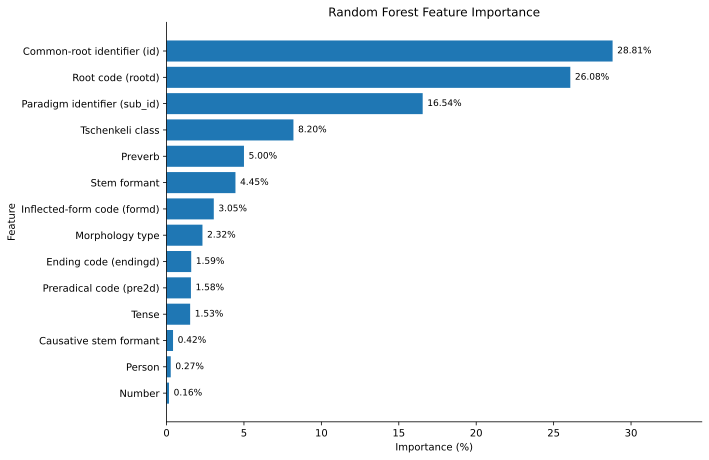

In [18]:
importance_df = pd.DataFrame({
    "feature": MODEL_FEATURES,
    "importance": standard_model.feature_importances_,
})


importance_df["importance_percent"] = (
    importance_df["importance"]
    * 100
)


importance_df = (
    importance_df
    .sort_values(
        "importance",
        ascending=False
    )
    .reset_index(drop=True)
)


FEATURE_LABELS = {
    "id": "Common-root identifier (id)",
    "rootd": "Root code (rootd)",
    "sub_id": "Paradigm identifier (sub_id)",
    "tsch_class": "Tschenkeli class",
    "preverb": "Preverb",
    "sf2": "Stem formant",
    "formd": "Inflected-form code (formd)",
    "morph_type": "Morphology type",
    "endingd": "Ending code (endingd)",
    "pre2d": "Preradical code (pre2d)",
    "tense": "Tense",
    "caus_sf": "Causative stem formant",
    "person": "Person",
    "number": "Number",
}


importance_df["display_name"] = (
    importance_df["feature"]
    .map(FEATURE_LABELS)
)


print("Random Forest feature importance:")

display(
    importance_df[
        [
            "feature",
            "importance",
            "importance_percent",
        ]
    ]
)


importance_df.to_csv(
    RESULTS_DIR / "feature_importance.csv",
    index=False
)


# --------------------------------------------------
# Plot
# --------------------------------------------------

plot_df = (
    importance_df
    .sort_values(
        "importance_percent",
        ascending=True
    )
)


fig, ax = plt.subplots(
    figsize=(10, 6.5)
)


bars = ax.barh(
    plot_df["display_name"],
    plot_df["importance_percent"]
)


for bar, percentage in zip(
    bars,
    plot_df["importance_percent"]
):

    ax.text(
        bar.get_width() + 0.3,
        bar.get_y() + bar.get_height() / 2,
        f"{percentage:.2f}%",
        va="center",
        fontsize=9
    )


ax.set_title(
    "Random Forest Feature Importance"
)

ax.set_xlabel(
    "Importance (%)"
)

ax.set_ylabel(
    "Feature"
)


maximum_importance = (
    plot_df["importance_percent"].max()
)

ax.set_xlim(
    0,
    maximum_importance * 1.20
)


ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)


fig.tight_layout()


fig.savefig(
    FIGURES_DIR / "random_forest_feature_importance.pdf",
    bbox_inches="tight"
)

fig.savefig(
    FIGURES_DIR / "random_forest_feature_importance.svg",
    bbox_inches="tight"
)

fig.savefig(
    FIGURES_DIR / "random_forest_feature_importance.png",
    dpi=600,
    bbox_inches="tight"
)


plt.show()

In [19]:
top_features = (
    importance_df
    .head(3)
)

top_features_md = "\n".join(
    f"- `{row.feature}`: **{row.importance_percent:.2f}%**"
    for row in top_features.itertuples()
)

id_importance = (
    importance_df.loc[
        importance_df["feature"] == "id",
        "importance_percent"
    ].iloc[0]
)

sub_id_importance = (
    importance_df.loc[
        importance_df["feature"] == "sub_id",
        "importance_percent"
    ].iloc[0]
)

display(Markdown(f"""
### Interpretation of feature importance

The three largest impurity-based feature-importance values in the fitted Random Forest are:

{top_features_md}

The common-root identifier `id` has an importance of **{id_importance:.2f}%**, while the paradigm sub-identifier `sub_id` has an importance of **{sub_id_importance:.2f}%**.

These values describe how strongly the **fitted Random Forest** relied on each variable. They must not be interpreted as direct measurements of linguistic importance.

This distinction is particularly important for `id` and `sub_id`. These variables encode structural organization in the source resource rather than grammatical properties in themselves. Their importance therefore shows that the model makes substantial use of lexical and group-related information learned from the training data.

This observation is consistent with the evaluation results. Row-level prediction is very strong when related lexical and paradigmatic structures may be represented in both training and test data, whereas prediction for held-out complete `raw_sub_id` paradigms is substantially more difficult.

Impurity-based feature importance may also favour variables having many distinct possible values. The reported percentages should therefore be interpreted primarily as descriptive properties of the fitted model. The ablation experiments below provide a more direct test of the predictive contribution of `id` and `sub_id`.
"""))


### Interpretation of feature importance

The three largest impurity-based feature-importance values in the fitted Random Forest are:

- `id`: **28.81%**
- `rootd`: **26.08%**
- `sub_id`: **16.54%**

The common-root identifier `id` has an importance of **28.81%**, while the paradigm sub-identifier `sub_id` has an importance of **16.54%**.

These values describe how strongly the **fitted Random Forest** relied on each variable. They must not be interpreted as direct measurements of linguistic importance.

This distinction is particularly important for `id` and `sub_id`. These variables encode structural organization in the source resource rather than grammatical properties in themselves. Their importance therefore shows that the model makes substantial use of lexical and group-related information learned from the training data.

This observation is consistent with the evaluation results. Row-level prediction is very strong when related lexical and paradigmatic structures may be represented in both training and test data, whereas prediction for held-out complete `raw_sub_id` paradigms is substantially more difficult.

Impurity-based feature importance may also favour variables having many distinct possible values. The reported percentages should therefore be interpreted primarily as descriptive properties of the fitted model. The ablation experiments below provide a more direct test of the predictive contribution of `id` and `sub_id`.


## 10. Ablation Analysis of Identifier-Related Features

The feature-importance analysis shows that the identifier-related variables `id` and `sub_id` contribute substantially to the fitted Random Forest. However, impurity-based feature importance alone does not show how strongly predictive performance depends on a particular variable. To examine this directly, three ablation experiments are performed:

1. remove `id` while retaining `sub_id`;
2. remove `sub_id` while retaining `id`;
3. remove both `id` and `sub_id`.

All other preprocessing steps, Random Forest parameters, train/test settings, and evaluation procedures are kept unchanged.

The distinction between the identifier-related variables is important:

- `id` is the **common-root identifier**;
- `raw_sub_id` is the **complete original paradigm identifier**, combining the common-root identifier with a paradigm-specific suffix;
- the processed `sub_id` used by the Random Forest is only the **paradigm sub-identifier**, i.e. the suffix extracted from `raw_sub_id`.

The complete `raw_sub_id` is **not used as a predictive feature**. It is retained only as the grouping variable for `GroupShuffleSplit` and `GroupKFold`, ensuring that all records belonging to the same complete paradigm are assigned to only one side of a grouped split.

### 10.1 Ablation of `id`

The first experiment removes the common-root identifier `id` while retaining all other features, including the processed `sub_id`.

This experiment evaluates how much the Random Forest depends on common-root information. Particular attention is given to the group-based evaluations, because different `raw_sub_id` paradigms sharing the same `id` may otherwise occur in both training and test partitions.

In [20]:
# ==================================================
# Ablation experiment: Random Forest WITHOUT "id"
# ==================================================

print("=" * 70)
print('ABLATION EXPERIMENT: RANDOM FOREST WITHOUT "id"')
print("=" * 70)


# --------------------------------------------------
# 1. Remove "id" from the feature matrix
# --------------------------------------------------

X_no_id = X.drop(
    columns=["id"]
).copy()

print("\nOriginal number of features:", X.shape[1])
print("Number of features without id:", X_no_id.shape[1])
print("\nFeatures used:")
print(list(X_no_id.columns))


# ==================================================
# 2. Standard 80/20 row-level evaluation
# ==================================================

X_train_no_id, X_test_no_id, y_train_no_id, y_test_no_id = train_test_split(
    X_no_id,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE
)


rf_no_id = RandomForestClassifier(
    **RF_PARAMS
)

rf_no_id.fit(
    X_train_no_id,
    y_train_no_id
)


pred_no_id = rf_no_id.predict(
    X_test_no_id
)


train_accuracy_no_id = accuracy_score(
    y_train_no_id,
    rf_no_id.predict(X_train_no_id)
)

test_accuracy_no_id = accuracy_score(
    y_test_no_id,
    pred_no_id
)

oob_accuracy_no_id = rf_no_id.oob_score_


report_no_id = classification_report(
    y_test_no_id,
    pred_no_id,
    output_dict=True,
    zero_division=0
)


weighted_precision_no_id = (
    report_no_id["weighted avg"]["precision"]
)

weighted_recall_no_id = (
    report_no_id["weighted avg"]["recall"]
)

weighted_f1_no_id = (
    report_no_id["weighted avg"]["f1-score"]
)

macro_f1_no_id = (
    report_no_id["macro avg"]["f1-score"]
)


print("\n" + "-" * 70)
print("STANDARD 80/20 ROW-LEVEL EVALUATION")
print("-" * 70)

print(f"Train accuracy:     {train_accuracy_no_id * 100:.4f}%")
print(f"Test accuracy:      {test_accuracy_no_id * 100:.4f}%")
print(f"OOB accuracy:       {oob_accuracy_no_id * 100:.4f}%")
print(f"Weighted precision: {weighted_precision_no_id:.4f}")
print(f"Weighted recall:    {weighted_recall_no_id:.4f}")
print(f"Weighted F1:        {weighted_f1_no_id:.4f}")
print(f"Macro F1:           {macro_f1_no_id:.4f}")


# ==================================================
# 3. Five-fold KFold
# ==================================================

kf_no_id = KFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)


kfold_scores_no_id = []


for fold, (train_idx, test_idx) in enumerate(
    kf_no_id.split(X_no_id),
    start=1
):

    fold_model = RandomForestClassifier(
        **RF_PARAMS
    )

    fold_model.fit(
        X_no_id.iloc[train_idx],
        y.iloc[train_idx]
    )

    fold_predictions = fold_model.predict(
        X_no_id.iloc[test_idx]
    )

    fold_accuracy = accuracy_score(
        y.iloc[test_idx],
        fold_predictions
    )

    kfold_scores_no_id.append(
        fold_accuracy
    )

    print(
        f"KFold {fold}: "
        f"{fold_accuracy * 100:.4f}%"
    )


kfold_mean_no_id = np.mean(
    kfold_scores_no_id
)

kfold_std_no_id = np.std(
    kfold_scores_no_id,
    ddof=1
)


print("\n" + "-" * 70)
print("FIVE-FOLD KFOLD")
print("-" * 70)

print(
    f"Mean accuracy: "
    f"{kfold_mean_no_id * 100:.4f}%"
)

print(
    f"Standard deviation: "
    f"{kfold_std_no_id * 100:.4f} pp"
)


# ==================================================
# 4. GroupShuffleSplit
# ==================================================

gss_no_id = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=RANDOM_STATE
)


train_idx, test_idx = next(
    gss_no_id.split(
        X_no_id,
        y,
        groups=groups_raw_sub_id
    )
)


X_train_gss_no_id = X_no_id.iloc[train_idx]
X_test_gss_no_id = X_no_id.iloc[test_idx]

y_train_gss_no_id = y.iloc[train_idx]
y_test_gss_no_id = y.iloc[test_idx]


gss_model_no_id = RandomForestClassifier(
    **RF_PARAMS
)

gss_model_no_id.fit(
    X_train_gss_no_id,
    y_train_gss_no_id
)


gss_pred_no_id = gss_model_no_id.predict(
    X_test_gss_no_id
)


gss_accuracy_no_id = accuracy_score(
    y_test_gss_no_id,
    gss_pred_no_id
)


gss_report_no_id = classification_report(
    y_test_gss_no_id,
    gss_pred_no_id,
    output_dict=True,
    zero_division=0
)


gss_weighted_f1_no_id = (
    gss_report_no_id["weighted avg"]["f1-score"]
)

gss_macro_f1_no_id = (
    gss_report_no_id["macro avg"]["f1-score"]
)


group_overlap_no_id = len(
    set(groups_raw_sub_id.iloc[train_idx])
    &
    set(groups_raw_sub_id.iloc[test_idx])
)


print("\n" + "-" * 70)
print("GROUP SHUFFLE SPLIT")
print("-" * 70)

print(
    f"Test accuracy: {gss_accuracy_no_id * 100:.4f}%"
)

print(
    f"Weighted F1:   {gss_weighted_f1_no_id:.4f}"
)

print(
    f"Macro F1:      {gss_macro_f1_no_id:.4f}"
)

print(
    f"Group overlap: {group_overlap_no_id}"
)


# ==================================================
# 5. Five-fold GroupKFold
# ==================================================

gkf_no_id = GroupKFold(
    n_splits=5
)


group_kfold_scores_no_id = []


for fold, (train_idx, test_idx) in enumerate(
    gkf_no_id.split(
        X_no_id,
        y,
        groups=groups_raw_sub_id
    ),
    start=1
):

    fold_model = RandomForestClassifier(
        **RF_PARAMS
    )

    fold_model.fit(
        X_no_id.iloc[train_idx],
        y.iloc[train_idx]
    )

    fold_predictions = fold_model.predict(
        X_no_id.iloc[test_idx]
    )

    fold_accuracy = accuracy_score(
        y.iloc[test_idx],
        fold_predictions
    )

    group_kfold_scores_no_id.append(
        fold_accuracy
    )

    overlap = len(
        set(groups_raw_sub_id.iloc[train_idx])
        &
        set(groups_raw_sub_id.iloc[test_idx])
    )

    print(
        f"GroupKFold {fold}: "
        f"{fold_accuracy * 100:.4f}% "
        f"(group overlap = {overlap})"
    )


group_kfold_mean_no_id = np.mean(
    group_kfold_scores_no_id
)

group_kfold_std_no_id = np.std(
    group_kfold_scores_no_id,
    ddof=1
)


print("\n" + "-" * 70)
print("FIVE-FOLD GROUPKFOLD")
print("-" * 70)

print(
    f"Mean accuracy: "
    f"{group_kfold_mean_no_id * 100:.4f}%"
)

print(
    f"Standard deviation: "
    f"{group_kfold_std_no_id * 100:.4f} pp"
)


# ==================================================
# 6. Compare with the original model
# ==================================================

comparison_no_id = pd.DataFrame({

    "Evaluation": [
        "Standard 80/20",
        "OOB",
        "Five-fold KFold",
        "GroupShuffleSplit",
        "Five-fold GroupKFold",
    ],

    "Original (%)": [
        test_accuracy * 100,
        oob_accuracy * 100,
        kf_results_df["test_accuracy"].mean() * 100,
        gss_test_accuracy * 100,
        group_kfold_results_df["test_accuracy"].mean() * 100,
    ],

    "Without id (%)": [
        test_accuracy_no_id * 100,
        oob_accuracy_no_id * 100,
        kfold_mean_no_id * 100,
        gss_accuracy_no_id * 100,
        group_kfold_mean_no_id * 100,
    ],
})


comparison_no_id["Difference (pp)"] = (
    comparison_no_id["Without id (%)"]
    -
    comparison_no_id["Original (%)"]
)


comparison_no_id = comparison_no_id.round({
    "Original (%)": 4,
    "Without id (%)": 4,
    "Difference (pp)": 4,
})


print("\n" + "=" * 70)
print("COMPARISON: ORIGINAL MODEL vs MODEL WITHOUT id")
print("=" * 70)

display(
    comparison_no_id
)


comparison_no_id.to_csv(
    RESULTS_DIR / "ablation_without_id.csv",
    index=False
)

ABLATION EXPERIMENT: RANDOM FOREST WITHOUT "id"

Original number of features: 14
Number of features without id: 13

Features used:
['formd', 'tense', 'person', 'number', 'preverb', 'pre2d', 'rootd', 'sf2', 'caus_sf', 'endingd', 'tsch_class', 'morph_type', 'sub_id']

----------------------------------------------------------------------
STANDARD 80/20 ROW-LEVEL EVALUATION
----------------------------------------------------------------------
Train accuracy:     99.7171%
Test accuracy:      97.8857%
OOB accuracy:       97.7564%
Weighted precision: 0.9792
Weighted recall:    0.9789
Weighted F1:        0.9789
Macro F1:           0.9667
KFold 1: 97.9095%
KFold 2: 97.9299%
KFold 3: 98.0317%
KFold 4: 97.9349%
KFold 5: 97.8976%

----------------------------------------------------------------------
FIVE-FOLD KFOLD
----------------------------------------------------------------------
Mean accuracy: 97.9407%
Standard deviation: 0.0530 pp

--------------------------------------------------------

,Evaluation,Original (%),Without id (%),Difference (pp)
0,Standard 80/20,99.9067,97.8857,-2.0209
1,OOB,99.9113,97.7564,-2.1550
2,Five-fold KFold,99.9162,97.9407,-1.9755
3,GroupShuffleSplit,65.3409,39.4723,-25.8686
4,Five-fold GroupKFold,67.5937,46.2539,-21.3398


In [21]:
original_kfold_mean = (
    kf_results_df["test_accuracy"].mean()
)

original_groupkfold_mean = (
    group_kfold_results_df["test_accuracy"].mean()
)

row_drop_no_id = (
    test_accuracy
    - test_accuracy_no_id
)

gss_drop_no_id = (
    gss_test_accuracy
    - gss_accuracy_no_id
)

gkf_drop_no_id = (
    original_groupkfold_mean
    - group_kfold_mean_no_id
)

display(Markdown(f"""
#### Interpretation

Removing `id` reduces standard row-level test accuracy from **{pct(test_accuracy)} to {pct(test_accuracy_no_id)}**, a decrease of **{pp(row_drop_no_id)}**. Mean five-fold KFold accuracy decreases from **{pct(original_kfold_mean)} to {pct(kfold_mean_no_id)}**.

The effect is considerably stronger under group-based evaluation:

- GroupShuffleSplit decreases from **{pct(gss_test_accuracy)} to {pct(gss_accuracy_no_id)}**, a reduction of **{pp(gss_drop_no_id)}**;
- mean GroupKFold accuracy decreases from **{pct(original_groupkfold_mean)} to {pct(group_kfold_mean_no_id)}**, a reduction of **{pp(gkf_drop_no_id)}**.

These results show that the common-root identifier carries substantial predictive information, particularly when complete `raw_sub_id` paradigms are held out. The result is consistent with its high Random Forest feature importance.

This should not be interpreted as evidence that `id` is linguistically more important than the morphological features. Rather, it demonstrates that the structural organization represented by the common-root identifier is highly informative for this prediction task.
"""))


#### Interpretation

Removing `id` reduces standard row-level test accuracy from **99.91% to 97.89%**, a decrease of **2.02 pp**. Mean five-fold KFold accuracy decreases from **99.92% to 97.94%**.

The effect is considerably stronger under group-based evaluation:

- GroupShuffleSplit decreases from **65.34% to 39.47%**, a reduction of **25.87 pp**;
- mean GroupKFold accuracy decreases from **67.59% to 46.25%**, a reduction of **21.34 pp**.

These results show that the common-root identifier carries substantial predictive information, particularly when complete `raw_sub_id` paradigms are held out. The result is consistent with its high Random Forest feature importance.

This should not be interpreted as evidence that `id` is linguistically more important than the morphological features. Rather, it demonstrates that the structural organization represented by the common-root identifier is highly informative for this prediction task.


In [22]:
# --------------------------------------------------
# Release memory used by ablation experiment: without id
# --------------------------------------------------

del X_no_id
del X_train_no_id, X_test_no_id
del y_train_no_id, y_test_no_id

del rf_no_id
del pred_no_id
del report_no_id

del kf_no_id
del kfold_scores_no_id

del gss_no_id
del X_train_gss_no_id, X_test_gss_no_id
del y_train_gss_no_id, y_test_gss_no_id
del gss_model_no_id
del gss_pred_no_id
del gss_report_no_id

del gkf_no_id
del group_kfold_scores_no_id

# Objects left from the last CV fold
del fold_model
del fold_predictions
del train_idx, test_idx

# Small comparison table is already saved to CSV
del comparison_no_id

gc.collect()

print("Memory from ablation experiment 10.1 released.")

Memory from ablation experiment 10.1 released.


### 10.2 Ablation of `sub_id`

The second experiment removes the processed paradigm sub-identifier `sub_id` while retaining the common-root identifier `id`.

The grouping procedure remains unchanged: `raw_sub_id` is still used only to construct disjoint groups for `GroupShuffleSplit` and `GroupKFold`.

This experiment examines whether the paradigm suffix encoded by `sub_id` contributes information beyond that already provided by the common-root identifier and the linguistic features.

In [23]:
# ==================================================
# Ablation experiment: Random Forest WITHOUT "sub_id"
# "id" remains included as a model feature.
# Group-based evaluation still uses raw_sub_id
# only to define disjoint train/test groups.
# ==================================================

print("=" * 70)
print('ABLATION EXPERIMENT: RANDOM FOREST WITHOUT "sub_id"')
print("=" * 70)


# --------------------------------------------------
# 1. Remove "sub_id" from the feature matrix
# --------------------------------------------------

X_no_sub_id = X.drop(
    columns=["sub_id"]
).copy()

print("\nOriginal number of features:", X.shape[1])
print("Number of features without sub_id:", X_no_sub_id.shape[1])

print("\nFeatures used:")
print(list(X_no_sub_id.columns))


# ==================================================
# 2. Standard 80/20 row-level evaluation
# ==================================================

X_train_no_sub_id, X_test_no_sub_id, y_train_no_sub_id, y_test_no_sub_id = (
    train_test_split(
        X_no_sub_id,
        y,
        test_size=0.20,
        random_state=RANDOM_STATE
    )
)


rf_no_sub_id = RandomForestClassifier(
    **RF_PARAMS
)

rf_no_sub_id.fit(
    X_train_no_sub_id,
    y_train_no_sub_id
)


pred_no_sub_id = rf_no_sub_id.predict(
    X_test_no_sub_id
)


train_accuracy_no_sub_id = accuracy_score(
    y_train_no_sub_id,
    rf_no_sub_id.predict(X_train_no_sub_id)
)

test_accuracy_no_sub_id = accuracy_score(
    y_test_no_sub_id,
    pred_no_sub_id
)

oob_accuracy_no_sub_id = rf_no_sub_id.oob_score_


report_no_sub_id = classification_report(
    y_test_no_sub_id,
    pred_no_sub_id,
    output_dict=True,
    zero_division=0
)


weighted_precision_no_sub_id = (
    report_no_sub_id["weighted avg"]["precision"]
)

weighted_recall_no_sub_id = (
    report_no_sub_id["weighted avg"]["recall"]
)

weighted_f1_no_sub_id = (
    report_no_sub_id["weighted avg"]["f1-score"]
)

macro_f1_no_sub_id = (
    report_no_sub_id["macro avg"]["f1-score"]
)


print("\n" + "-" * 70)
print("STANDARD 80/20 ROW-LEVEL EVALUATION")
print("-" * 70)

print(f"Train accuracy:     {train_accuracy_no_sub_id * 100:.4f}%")
print(f"Test accuracy:      {test_accuracy_no_sub_id * 100:.4f}%")
print(f"OOB accuracy:       {oob_accuracy_no_sub_id * 100:.4f}%")
print(f"Weighted precision: {weighted_precision_no_sub_id:.4f}")
print(f"Weighted recall:    {weighted_recall_no_sub_id:.4f}")
print(f"Weighted F1:        {weighted_f1_no_sub_id:.4f}")
print(f"Macro F1:           {macro_f1_no_sub_id:.4f}")


# ==================================================
# 3. Five-fold KFold
# ==================================================

kf_no_sub_id = KFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)


kfold_scores_no_sub_id = []


for fold, (train_idx, test_idx) in enumerate(
    kf_no_sub_id.split(X_no_sub_id),
    start=1
):

    fold_model = RandomForestClassifier(
        **RF_PARAMS
    )

    fold_model.fit(
        X_no_sub_id.iloc[train_idx],
        y.iloc[train_idx]
    )

    fold_predictions = fold_model.predict(
        X_no_sub_id.iloc[test_idx]
    )

    fold_accuracy = accuracy_score(
        y.iloc[test_idx],
        fold_predictions
    )

    kfold_scores_no_sub_id.append(
        fold_accuracy
    )

    print(
        f"KFold {fold}: "
        f"{fold_accuracy * 100:.4f}%"
    )


kfold_mean_no_sub_id = np.mean(
    kfold_scores_no_sub_id
)

kfold_std_no_sub_id = np.std(
    kfold_scores_no_sub_id,
    ddof=1
)


print("\n" + "-" * 70)
print("FIVE-FOLD KFOLD")
print("-" * 70)

print(
    f"Mean accuracy: "
    f"{kfold_mean_no_sub_id * 100:.4f}%"
)

print(
    f"Standard deviation: "
    f"{kfold_std_no_sub_id * 100:.4f} pp"
)


# ==================================================
# 4. GroupShuffleSplit
#
# NOTE:
# sub_id is NOT used as a model feature here.
# raw_sub_id is used only to define disjoint groups
# for the evaluation split.
# ==================================================

gss_no_sub_id = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=RANDOM_STATE
)


train_idx, test_idx = next(
    gss_no_sub_id.split(
        X_no_sub_id,
        y,
        groups=groups_raw_sub_id
    )
)


X_train_gss_no_sub_id = X_no_sub_id.iloc[train_idx]
X_test_gss_no_sub_id = X_no_sub_id.iloc[test_idx]

y_train_gss_no_sub_id = y.iloc[train_idx]
y_test_gss_no_sub_id = y.iloc[test_idx]


gss_model_no_sub_id = RandomForestClassifier(
    **RF_PARAMS
)

gss_model_no_sub_id.fit(
    X_train_gss_no_sub_id,
    y_train_gss_no_sub_id
)


gss_pred_no_sub_id = gss_model_no_sub_id.predict(
    X_test_gss_no_sub_id
)


gss_accuracy_no_sub_id = accuracy_score(
    y_test_gss_no_sub_id,
    gss_pred_no_sub_id
)


gss_report_no_sub_id = classification_report(
    y_test_gss_no_sub_id,
    gss_pred_no_sub_id,
    output_dict=True,
    zero_division=0
)


gss_weighted_precision_no_sub_id = (
    gss_report_no_sub_id["weighted avg"]["precision"]
)

gss_weighted_recall_no_sub_id = (
    gss_report_no_sub_id["weighted avg"]["recall"]
)

gss_weighted_f1_no_sub_id = (
    gss_report_no_sub_id["weighted avg"]["f1-score"]
)

gss_macro_f1_no_sub_id = (
    gss_report_no_sub_id["macro avg"]["f1-score"]
)


group_overlap_no_sub_id = len(
    set(groups_raw_sub_id.iloc[train_idx])
    &
    set(groups_raw_sub_id.iloc[test_idx])
)


print("\n" + "-" * 70)
print("GROUP SHUFFLE SPLIT")
print("-" * 70)

print(
    f"Test accuracy:      "
    f"{gss_accuracy_no_sub_id * 100:.4f}%"
)

print(
    f"Weighted precision: "
    f"{gss_weighted_precision_no_sub_id:.4f}"
)

print(
    f"Weighted recall:    "
    f"{gss_weighted_recall_no_sub_id:.4f}"
)

print(
    f"Weighted F1:        "
    f"{gss_weighted_f1_no_sub_id:.4f}"
)

print(
    f"Macro F1:           "
    f"{gss_macro_f1_no_sub_id:.4f}"
)

print(
    f"Group overlap:      "
    f"{group_overlap_no_sub_id}"
)


# ==================================================
# 5. Five-fold GroupKFold
#
# Again, raw_sub_id is used only for grouping.
# It is not present in the feature matrix.
# ==================================================

gkf_no_sub_id = GroupKFold(
    n_splits=5
)


group_kfold_scores_no_sub_id = []


for fold, (train_idx, test_idx) in enumerate(
    gkf_no_sub_id.split(
        X_no_sub_id,
        y,
        groups=groups_raw_sub_id
    ),
    start=1
):

    fold_model = RandomForestClassifier(
        **RF_PARAMS
    )

    fold_model.fit(
        X_no_sub_id.iloc[train_idx],
        y.iloc[train_idx]
    )

    fold_predictions = fold_model.predict(
        X_no_sub_id.iloc[test_idx]
    )

    fold_accuracy = accuracy_score(
        y.iloc[test_idx],
        fold_predictions
    )

    group_kfold_scores_no_sub_id.append(
        fold_accuracy
    )


    overlap = len(
        set(groups_raw_sub_id.iloc[train_idx])
        &
        set(groups_raw_sub_id.iloc[test_idx])
    )


    print(
        f"GroupKFold {fold}: "
        f"{fold_accuracy * 100:.4f}% "
        f"(group overlap = {overlap})"
    )


group_kfold_mean_no_sub_id = np.mean(
    group_kfold_scores_no_sub_id
)

group_kfold_std_no_sub_id = np.std(
    group_kfold_scores_no_sub_id,
    ddof=1
)


print("\n" + "-" * 70)
print("FIVE-FOLD GROUPKFOLD")
print("-" * 70)

print(
    f"Mean accuracy: "
    f"{group_kfold_mean_no_sub_id * 100:.4f}%"
)

print(
    f"Standard deviation: "
    f"{group_kfold_std_no_sub_id * 100:.4f} pp"
)


# ==================================================
# 6. Compare with the original 14-feature model
# ==================================================

comparison_no_sub_id = pd.DataFrame({

    "Evaluation": [
        "Standard 80/20",
        "OOB",
        "Five-fold KFold",
        "GroupShuffleSplit",
        "Five-fold GroupKFold",
    ],

    "Original (%)": [
        test_accuracy * 100,
        oob_accuracy * 100,
        kf_results_df["test_accuracy"].mean() * 100,
        gss_test_accuracy * 100,
        group_kfold_results_df["test_accuracy"].mean() * 100,
    ],

    "Without sub_id (%)": [
        test_accuracy_no_sub_id * 100,
        oob_accuracy_no_sub_id * 100,
        kfold_mean_no_sub_id * 100,
        gss_accuracy_no_sub_id * 100,
        group_kfold_mean_no_sub_id * 100,
    ],
})


comparison_no_sub_id["Difference (pp)"] = (
    comparison_no_sub_id["Without sub_id (%)"]
    -
    comparison_no_sub_id["Original (%)"]
)


comparison_no_sub_id = comparison_no_sub_id.round({
    "Original (%)": 4,
    "Without sub_id (%)": 4,
    "Difference (pp)": 4,
})


print("\n" + "=" * 70)
print("COMPARISON: ORIGINAL MODEL vs MODEL WITHOUT sub_id")
print("=" * 70)

display(
    comparison_no_sub_id
)


comparison_no_sub_id.to_csv(
    RESULTS_DIR / "ablation_without_sub_id.csv",
    index=False
)

ABLATION EXPERIMENT: RANDOM FOREST WITHOUT "sub_id"

Original number of features: 14
Number of features without sub_id: 13

Features used:
['formd', 'tense', 'person', 'number', 'preverb', 'pre2d', 'rootd', 'sf2', 'caus_sf', 'endingd', 'tsch_class', 'morph_type', 'id']

----------------------------------------------------------------------
STANDARD 80/20 ROW-LEVEL EVALUATION
----------------------------------------------------------------------
Train accuracy:     99.2945%
Test accuracy:      98.4983%
OOB accuracy:       98.5284%
Weighted precision: 0.9849
Weighted recall:    0.9850
Weighted F1:        0.9846
Macro F1:           0.9766
KFold 1: 98.5102%
KFold 2: 98.5628%
KFold 3: 98.5916%
KFold 4: 98.6849%
KFold 5: 98.4745%

----------------------------------------------------------------------
FIVE-FOLD KFOLD
----------------------------------------------------------------------
Mean accuracy: 98.5648%
Standard deviation: 0.0811 pp

----------------------------------------------------

,Evaluation,Original (%),Without sub_id (%),Difference (pp)
0,Standard 80/20,99.9067,98.4983,-1.4084
1,OOB,99.9113,98.5284,-1.3829
2,Five-fold KFold,99.9162,98.5648,-1.3514
3,GroupShuffleSplit,65.3409,67.0256,1.6847
4,Five-fold GroupKFold,67.5937,68.4177,0.8240


In [24]:
original_kfold_mean = (
    kf_results_df["test_accuracy"].mean()
)

original_groupkfold_mean = (
    group_kfold_results_df["test_accuracy"].mean()
)

row_drop_no_sub_id = (
    test_accuracy
    - test_accuracy_no_sub_id
)

gss_change_no_sub_id = (
    gss_accuracy_no_sub_id
    - gss_test_accuracy
)

gkf_change_no_sub_id = (
    group_kfold_mean_no_sub_id
    - original_groupkfold_mean
)

display(Markdown(f"""
#### Interpretation

Removing `sub_id` reduces standard row-level test accuracy from **{pct(test_accuracy)} to {pct(test_accuracy_no_sub_id)}**, a decrease of **{pp(row_drop_no_sub_id)}**. Mean five-fold KFold accuracy decreases from **{pct(original_kfold_mean)} to {pct(kfold_mean_no_sub_id)}**.

In contrast, group-based performance does not decrease in this run:

- GroupShuffleSplit changes from **{pct(gss_test_accuracy)} to {pct(gss_accuracy_no_sub_id)}** ({pp(gss_change_no_sub_id)} change);
- mean GroupKFold accuracy changes from **{pct(original_groupkfold_mean)} to {pct(group_kfold_mean_no_sub_id)}** ({pp(gkf_change_no_sub_id)} change).

These small increases should not be interpreted as evidence that removing `sub_id` necessarily improves generalization. The GroupKFold difference is small relative to its fold-to-fold variation of **{pp(group_kfold_std_no_sub_id)}**, and GroupShuffleSplit represents only one grouped split.

The experiment nevertheless shows that the processed `sub_id` feature is not required to maintain the observed performance on held-out `raw_sub_id` paradigm groups. This contrasts with the much stronger effect observed when `id` is removed.
"""))


#### Interpretation

Removing `sub_id` reduces standard row-level test accuracy from **99.91% to 98.50%**, a decrease of **1.41 pp**. Mean five-fold KFold accuracy decreases from **99.92% to 98.56%**.

In contrast, group-based performance does not decrease in this run:

- GroupShuffleSplit changes from **65.34% to 67.03%** (1.68 pp change);
- mean GroupKFold accuracy changes from **67.59% to 68.42%** (0.82 pp change).

These small increases should not be interpreted as evidence that removing `sub_id` necessarily improves generalization. The GroupKFold difference is small relative to its fold-to-fold variation of **2.21 pp**, and GroupShuffleSplit represents only one grouped split.

The experiment nevertheless shows that the processed `sub_id` feature is not required to maintain the observed performance on held-out `raw_sub_id` paradigm groups. This contrasts with the much stronger effect observed when `id` is removed.


In [25]:
# --------------------------------------------------
# Release memory used by ablation experiment: without sub_id
# --------------------------------------------------

del X_no_sub_id
del X_train_no_sub_id, X_test_no_sub_id
del y_train_no_sub_id, y_test_no_sub_id

del rf_no_sub_id
del pred_no_sub_id
del report_no_sub_id

del kf_no_sub_id
del kfold_scores_no_sub_id

del gss_no_sub_id
del X_train_gss_no_sub_id, X_test_gss_no_sub_id
del y_train_gss_no_sub_id, y_test_gss_no_sub_id
del gss_model_no_sub_id
del gss_pred_no_sub_id
del gss_report_no_sub_id

del gkf_no_sub_id
del group_kfold_scores_no_sub_id

del fold_model
del fold_predictions
del train_idx, test_idx

del comparison_no_sub_id

gc.collect()

print("Memory from ablation experiment 10.2 released.")

Memory from ablation experiment 10.2 released.


### 10.3 Ablation of Both `id` and `sub_id`

The third experiment removes both identifier-related predictive variables. The Random Forest is therefore trained using only the remaining 12 morphological and form-derived features:

`formd`, `tense`, `person`, `number`, `preverb`, `pre2d`, `rootd`, `sf2`, `caus_sf`, `endingd`, `tsch_class`, and `morph_type`.

As in the preceding experiments, `raw_sub_id` remains available only for defining groups during group-based evaluation and is never supplied to the classifier.

This experiment provides the clearest estimate of how well verbal-noun prediction can be performed without the two identifier-derived structural features.

In [26]:
# ==================================================
# Ablation experiment: Random Forest WITHOUT
# both "id" and "sub_id"
#
# raw_sub_id is retained ONLY for defining groups
# in GroupShuffleSplit and GroupKFold.
# It is NOT used as a model feature.
# ==================================================

print("=" * 70)
print('ABLATION EXPERIMENT: RANDOM FOREST WITHOUT "id" AND "sub_id"')
print("=" * 70)


# --------------------------------------------------
# 1. Remove both identifier-related features
# --------------------------------------------------

X_no_ids = X.drop(
    columns=["id", "sub_id"]
).copy()


print("\nOriginal number of features:", X.shape[1])
print("Number of features without id and sub_id:", X_no_ids.shape[1])

print("\nFeatures used:")
print(list(X_no_ids.columns))


# ==================================================
# 2. Standard 80/20 row-level evaluation
# ==================================================

X_train_no_ids, X_test_no_ids, y_train_no_ids, y_test_no_ids = (
    train_test_split(
        X_no_ids,
        y,
        test_size=0.20,
        random_state=RANDOM_STATE
    )
)


rf_no_ids = RandomForestClassifier(
    **RF_PARAMS
)

rf_no_ids.fit(
    X_train_no_ids,
    y_train_no_ids
)


pred_no_ids = rf_no_ids.predict(
    X_test_no_ids
)


train_accuracy_no_ids = accuracy_score(
    y_train_no_ids,
    rf_no_ids.predict(X_train_no_ids)
)

test_accuracy_no_ids = accuracy_score(
    y_test_no_ids,
    pred_no_ids
)

oob_accuracy_no_ids = rf_no_ids.oob_score_


report_no_ids = classification_report(
    y_test_no_ids,
    pred_no_ids,
    output_dict=True,
    zero_division=0
)


weighted_precision_no_ids = (
    report_no_ids["weighted avg"]["precision"]
)

weighted_recall_no_ids = (
    report_no_ids["weighted avg"]["recall"]
)

weighted_f1_no_ids = (
    report_no_ids["weighted avg"]["f1-score"]
)

macro_f1_no_ids = (
    report_no_ids["macro avg"]["f1-score"]
)


print("\n" + "-" * 70)
print("STANDARD 80/20 ROW-LEVEL EVALUATION")
print("-" * 70)

print(f"Train accuracy:     {train_accuracy_no_ids * 100:.4f}%")
print(f"Test accuracy:      {test_accuracy_no_ids * 100:.4f}%")
print(f"OOB accuracy:       {oob_accuracy_no_ids * 100:.4f}%")
print(f"Weighted precision: {weighted_precision_no_ids:.4f}")
print(f"Weighted recall:    {weighted_recall_no_ids:.4f}")
print(f"Weighted F1:        {weighted_f1_no_ids:.4f}")
print(f"Macro F1:           {macro_f1_no_ids:.4f}")


# ==================================================
# 3. Five-fold KFold
# ==================================================

kf_no_ids = KFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)


kfold_scores_no_ids = []


for fold, (train_idx, test_idx) in enumerate(
    kf_no_ids.split(X_no_ids),
    start=1
):

    fold_model = RandomForestClassifier(
        **RF_PARAMS
    )

    fold_model.fit(
        X_no_ids.iloc[train_idx],
        y.iloc[train_idx]
    )

    fold_predictions = fold_model.predict(
        X_no_ids.iloc[test_idx]
    )

    fold_accuracy = accuracy_score(
        y.iloc[test_idx],
        fold_predictions
    )

    kfold_scores_no_ids.append(
        fold_accuracy
    )

    print(
        f"KFold {fold}: "
        f"{fold_accuracy * 100:.4f}%"
    )


kfold_mean_no_ids = np.mean(
    kfold_scores_no_ids
)

kfold_std_no_ids = np.std(
    kfold_scores_no_ids,
    ddof=1
)


print("\n" + "-" * 70)
print("FIVE-FOLD KFOLD")
print("-" * 70)

print(
    f"Mean accuracy: "
    f"{kfold_mean_no_ids * 100:.4f}%"
)

print(
    f"Standard deviation: "
    f"{kfold_std_no_ids * 100:.4f} pp"
)


# ==================================================
# 4. GroupShuffleSplit
#
# raw_sub_id is used ONLY to determine which rows
# belong to the same group. Neither id nor sub_id
# is available to the Random Forest.
# ==================================================

gss_no_ids = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=RANDOM_STATE
)


train_idx, test_idx = next(
    gss_no_ids.split(
        X_no_ids,
        y,
        groups=groups_raw_sub_id
    )
)


X_train_gss_no_ids = X_no_ids.iloc[train_idx]
X_test_gss_no_ids = X_no_ids.iloc[test_idx]

y_train_gss_no_ids = y.iloc[train_idx]
y_test_gss_no_ids = y.iloc[test_idx]


gss_model_no_ids = RandomForestClassifier(
    **RF_PARAMS
)

gss_model_no_ids.fit(
    X_train_gss_no_ids,
    y_train_gss_no_ids
)


gss_pred_no_ids = gss_model_no_ids.predict(
    X_test_gss_no_ids
)


gss_accuracy_no_ids = accuracy_score(
    y_test_gss_no_ids,
    gss_pred_no_ids
)


gss_report_no_ids = classification_report(
    y_test_gss_no_ids,
    gss_pred_no_ids,
    output_dict=True,
    zero_division=0
)


gss_weighted_precision_no_ids = (
    gss_report_no_ids["weighted avg"]["precision"]
)

gss_weighted_recall_no_ids = (
    gss_report_no_ids["weighted avg"]["recall"]
)

gss_weighted_f1_no_ids = (
    gss_report_no_ids["weighted avg"]["f1-score"]
)

gss_macro_f1_no_ids = (
    gss_report_no_ids["macro avg"]["f1-score"]
)


group_overlap_no_ids = len(
    set(groups_raw_sub_id.iloc[train_idx])
    &
    set(groups_raw_sub_id.iloc[test_idx])
)


print("\n" + "-" * 70)
print("GROUP SHUFFLE SPLIT")
print("-" * 70)

print(
    f"Test accuracy:      "
    f"{gss_accuracy_no_ids * 100:.4f}%"
)

print(
    f"Weighted precision: "
    f"{gss_weighted_precision_no_ids:.4f}"
)

print(
    f"Weighted recall:    "
    f"{gss_weighted_recall_no_ids:.4f}"
)

print(
    f"Weighted F1:        "
    f"{gss_weighted_f1_no_ids:.4f}"
)

print(
    f"Macro F1:           "
    f"{gss_macro_f1_no_ids:.4f}"
)

print(
    f"Group overlap:      "
    f"{group_overlap_no_ids}"
)


# ==================================================
# 5. Five-fold GroupKFold
# ==================================================

gkf_no_ids = GroupKFold(
    n_splits=5
)


group_kfold_scores_no_ids = []


for fold, (train_idx, test_idx) in enumerate(
    gkf_no_ids.split(
        X_no_ids,
        y,
        groups=groups_raw_sub_id
    ),
    start=1
):

    fold_model = RandomForestClassifier(
        **RF_PARAMS
    )

    fold_model.fit(
        X_no_ids.iloc[train_idx],
        y.iloc[train_idx]
    )

    fold_predictions = fold_model.predict(
        X_no_ids.iloc[test_idx]
    )

    fold_accuracy = accuracy_score(
        y.iloc[test_idx],
        fold_predictions
    )

    group_kfold_scores_no_ids.append(
        fold_accuracy
    )


    overlap = len(
        set(groups_raw_sub_id.iloc[train_idx])
        &
        set(groups_raw_sub_id.iloc[test_idx])
    )


    print(
        f"GroupKFold {fold}: "
        f"{fold_accuracy * 100:.4f}% "
        f"(group overlap = {overlap})"
    )


group_kfold_mean_no_ids = np.mean(
    group_kfold_scores_no_ids
)

group_kfold_std_no_ids = np.std(
    group_kfold_scores_no_ids,
    ddof=1
)


print("\n" + "-" * 70)
print("FIVE-FOLD GROUPKFOLD")
print("-" * 70)

print(
    f"Mean accuracy: "
    f"{group_kfold_mean_no_ids * 100:.4f}%"
)

print(
    f"Standard deviation: "
    f"{group_kfold_std_no_ids * 100:.4f} pp"
)


# ==================================================
# 6. Compare with the original 14-feature model
# ==================================================

comparison_no_ids = pd.DataFrame({

    "Evaluation": [
        "Standard 80/20",
        "OOB",
        "Five-fold KFold",
        "GroupShuffleSplit",
        "Five-fold GroupKFold",
    ],

    "Original (%)": [
        test_accuracy * 100,
        oob_accuracy * 100,
        kf_results_df["test_accuracy"].mean() * 100,
        gss_test_accuracy * 100,
        group_kfold_results_df["test_accuracy"].mean() * 100,
    ],

    "Without id + sub_id (%)": [
        test_accuracy_no_ids * 100,
        oob_accuracy_no_ids * 100,
        kfold_mean_no_ids * 100,
        gss_accuracy_no_ids * 100,
        group_kfold_mean_no_ids * 100,
    ],
})


comparison_no_ids["Difference (pp)"] = (
    comparison_no_ids["Without id + sub_id (%)"]
    -
    comparison_no_ids["Original (%)"]
)


comparison_no_ids = comparison_no_ids.round({
    "Original (%)": 4,
    "Without id + sub_id (%)": 4,
    "Difference (pp)": 4,
})


print("\n" + "=" * 70)
print(
    "COMPARISON: ORIGINAL MODEL vs "
    "MODEL WITHOUT id AND sub_id"
)
print("=" * 70)


display(
    comparison_no_ids
)


comparison_no_ids.to_csv(
    RESULTS_DIR / "ablation_without_id_and_sub_id.csv",
    index=False
)

ABLATION EXPERIMENT: RANDOM FOREST WITHOUT "id" AND "sub_id"

Original number of features: 14
Number of features without id and sub_id: 12

Features used:
['formd', 'tense', 'person', 'number', 'preverb', 'pre2d', 'rootd', 'sf2', 'caus_sf', 'endingd', 'tsch_class', 'morph_type']

----------------------------------------------------------------------
STANDARD 80/20 ROW-LEVEL EVALUATION
----------------------------------------------------------------------
Train accuracy:     97.3644%
Test accuracy:      85.7346%
OOB accuracy:       85.2443%
Weighted precision: 0.8596
Weighted recall:    0.8573
Weighted F1:        0.8564
Macro F1:           0.7801
KFold 1: 85.9417%
KFold 2: 85.7397%
KFold 3: 85.8908%
KFold 4: 85.3766%
KFold 5: 85.6091%

----------------------------------------------------------------------
FIVE-FOLD KFOLD
----------------------------------------------------------------------
Mean accuracy: 85.7116%
Standard deviation: 0.2283 pp

------------------------------------------

,Evaluation,Original (%),Without id + sub_id (%),Difference (pp)
0,Standard 80/20,99.9067,85.7346,-14.1720
1,OOB,99.9113,85.2443,-14.6671
2,Five-fold KFold,99.9162,85.7116,-14.2046
3,GroupShuffleSplit,65.3409,38.4553,-26.8856
4,Five-fold GroupKFold,67.5937,45.1777,-22.4160


In [27]:
original_kfold_mean = (
    kf_results_df["test_accuracy"].mean()
)

original_kfold_std = (
    kf_results_df["test_accuracy"].std()
)

original_groupkfold_mean = (
    group_kfold_results_df["test_accuracy"].mean()
)

original_groupkfold_std = (
    group_kfold_results_df["test_accuracy"].std()
)

row_drop_both = (
    test_accuracy
    - test_accuracy_no_ids
)

display(Markdown(f"""
#### Interpretation

Removing both `id` and `sub_id` produces the largest reduction in row-level performance. Standard test accuracy decreases from **{pct(test_accuracy)} to {pct(test_accuracy_no_ids)}**, a reduction of **{pp(row_drop_both)}**. Mean five-fold KFold accuracy decreases from **{pct(original_kfold_mean)} to {pct(kfold_mean_no_ids)}**.

Group-based performance is also substantially lower:

- GroupShuffleSplit accuracy: **{pct(gss_accuracy_no_ids)}**;
- mean GroupKFold accuracy: **{pct(group_kfold_mean_no_ids)} ± {pp(group_kfold_std_no_ids)}**.

The much larger row-level reduction obtained when both variables are removed, compared with removing either one individually, indicates that `id` and `sub_id` provide partially overlapping and mutually compensatory structural information. When either one remains available, the model retains considerably more information about the organization of the source data.

At the same time, the **{pct(test_accuracy_no_ids)} row-level accuracy obtained without either identifier-related feature** shows that the remaining **{X_no_ids.shape[1]} morphological and form-derived features** still contain substantial predictive information. The near-perfect performance of the complete model therefore cannot be attributed exclusively to identifier-related variables.

### 10.4 Summary of the Ablation Experiments

| Feature configuration | Standard split | OOB | Five-fold KFold | GroupShuffleSplit | Five-fold GroupKFold |
|---|---:|---:|---:|---:|---:|
| All {X.shape[1]} features | {pct(test_accuracy)} | {pct(oob_accuracy)} | {pct(original_kfold_mean)} ± {pp(original_kfold_std, 3)} | {pct(gss_test_accuracy)} | {pct(original_groupkfold_mean)} ± {pp(original_groupkfold_std)} |
| Without `id` | {pct(test_accuracy_no_id)} | {pct(oob_accuracy_no_id)} | {pct(kfold_mean_no_id)} ± {pp(kfold_std_no_id, 3)} | {pct(gss_accuracy_no_id)} | {pct(group_kfold_mean_no_id)} ± {pp(group_kfold_std_no_id)} |
| Without `sub_id` | {pct(test_accuracy_no_sub_id)} | {pct(oob_accuracy_no_sub_id)} | {pct(kfold_mean_no_sub_id)} ± {pp(kfold_std_no_sub_id, 3)} | {pct(gss_accuracy_no_sub_id)} | {pct(group_kfold_mean_no_sub_id)} ± {pp(group_kfold_std_no_sub_id)} |
| Without `id` and `sub_id` | {pct(test_accuracy_no_ids)} | {pct(oob_accuracy_no_ids)} | {pct(kfold_mean_no_ids)} ± {pp(kfold_std_no_ids, 3)} | {pct(gss_accuracy_no_ids)} | {pct(group_kfold_mean_no_ids)} ± {pp(group_kfold_std_no_ids)} |

The three ablation experiments reveal different roles for the two identifier-related features:

- `id` is particularly important in the group-based evaluation setting;
- `sub_id` contributes more clearly to row-level reconstruction but is not essential for maintaining performance on held-out `raw_sub_id` paradigms;
- the remaining morphological and form-derived features retain substantial predictive information even when both identifier-related variables are removed.

The ablation analysis also qualifies the interpretation of the near-perfect accuracy obtained by the complete model. A substantial part of its predictive performance derives from structural information encoded in the source resource, particularly through the common-root identifier. Consequently, high predictive agreement with the existing labels should not by itself be interpreted as proof of linguistic correctness or naturalness. This motivates complementary corpus-based and expert linguistic validation.
"""))


#### Interpretation

Removing both `id` and `sub_id` produces the largest reduction in row-level performance. Standard test accuracy decreases from **99.91% to 85.73%**, a reduction of **14.17 pp**. Mean five-fold KFold accuracy decreases from **99.92% to 85.71%**.

Group-based performance is also substantially lower:

- GroupShuffleSplit accuracy: **38.46%**;
- mean GroupKFold accuracy: **45.18% ± 1.92 pp**.

The much larger row-level reduction obtained when both variables are removed, compared with removing either one individually, indicates that `id` and `sub_id` provide partially overlapping and mutually compensatory structural information. When either one remains available, the model retains considerably more information about the organization of the source data.

At the same time, the **85.73% row-level accuracy obtained without either identifier-related feature** shows that the remaining **12 morphological and form-derived features** still contain substantial predictive information. The near-perfect performance of the complete model therefore cannot be attributed exclusively to identifier-related variables.

### 10.4 Summary of the Ablation Experiments

| Feature configuration | Standard split | OOB | Five-fold KFold | GroupShuffleSplit | Five-fold GroupKFold |
|---|---:|---:|---:|---:|---:|
| All 14 features | 99.91% | 99.91% | 99.92% ± 0.019 pp | 65.34% | 67.59% ± 2.03 pp |
| Without `id` | 97.89% | 97.76% | 97.94% ± 0.053 pp | 39.47% | 46.25% ± 2.10 pp |
| Without `sub_id` | 98.50% | 98.53% | 98.56% ± 0.081 pp | 67.03% | 68.42% ± 2.21 pp |
| Without `id` and `sub_id` | 85.73% | 85.24% | 85.71% ± 0.228 pp | 38.46% | 45.18% ± 1.92 pp |

The three ablation experiments reveal different roles for the two identifier-related features:

- `id` is particularly important in the group-based evaluation setting;
- `sub_id` contributes more clearly to row-level reconstruction but is not essential for maintaining performance on held-out `raw_sub_id` paradigms;
- the remaining morphological and form-derived features retain substantial predictive information even when both identifier-related variables are removed.

The ablation analysis also qualifies the interpretation of the near-perfect accuracy obtained by the complete model. A substantial part of its predictive performance derives from structural information encoded in the source resource, particularly through the common-root identifier. Consequently, high predictive agreement with the existing labels should not by itself be interpreted as proof of linguistic correctness or naturalness. This motivates complementary corpus-based and expert linguistic validation.


In [28]:
# --------------------------------------------------
# Release memory used by ablation experiment: without id and sub_id
# --------------------------------------------------

del X_no_ids
del X_train_no_ids, X_test_no_ids
del y_train_no_ids, y_test_no_ids

del rf_no_ids
del pred_no_ids
del report_no_ids

del kf_no_ids
del kfold_scores_no_ids

del gss_no_ids
del X_train_gss_no_ids, X_test_gss_no_ids
del y_train_gss_no_ids, y_test_gss_no_ids
del gss_model_no_ids
del gss_pred_no_ids
del gss_report_no_ids

del gkf_no_ids
del group_kfold_scores_no_ids

del fold_model
del fold_predictions
del train_idx, test_idx

del comparison_no_ids

gc.collect()

print("Memory from ablation experiment 10.3 released.")

Memory from ablation experiment 10.3 released.


## 11. Train the final Random Forest

The models used in the preceding sections are **evaluation models**.

They should not be used directly to reconstruct the final missing
verbal-noun values because each evaluation model was trained on only part
of the labelled dataset.

After evaluation is complete, a new **final Random Forest** is therefore
trained using **all available labelled records**.

This model is then used to predict verbal nouns in `data_vn-`.

In [29]:
final_model = RandomForestClassifier(
    **RF_PARAMS
)


final_model.fit(
    X,
    y
)


print(
    "Final model trained on labelled rows:",
    len(X)
)

print(
    "Final-model OOB score:",
    final_model.oob_score_
)


joblib.dump(
    final_model,
    MODELS_DIR / "kartuverbs_random_forest.joblib"
)


print(
    "Saved final model to:",
    MODELS_DIR / "kartuverbs_random_forest.joblib"
)

Final model trained on labelled rows: 294665
Final-model OOB score: 0.9990803115402237
Saved final model to: models/kartuverbs_random_forest.joblib


In [30]:
model_metadata = {
    "random_state": RANDOM_STATE,
    "n_estimators": N_ESTIMATORS,

    "model_features": MODEL_FEATURES,

    "categorical_mappings": CATEGORY_MAPPINGS,

    "verbal_noun_class_mapping": index_vn,

    "string_encoding": (
        "For each character, take the final UTF-8 byte and sum "
        "the byte values across the complete string."
    ),
}


with open(
    MODELS_DIR / "kartuverbs_model_metadata.json",
    "w",
    encoding="utf-8"
) as file:

    json.dump(
        model_metadata,
        file,
        ensure_ascii=False,
        indent=2
    )


print(
    "Saved model metadata to:",
    MODELS_DIR / "kartuverbs_model_metadata.json"
)

Saved model metadata to: models/kartuverbs_model_metadata.json


In [31]:
display(Markdown(f"""
### Confusion matrix visualization

The complete confusion matrix contains **{nfmt(len(class_report))} verbal-noun classes** and is therefore too large to visualize meaningfully as a single annotated matrix.

Two normalized confusion matrices are presented below:

1. the 20 most frequent verbal-noun classes in the test set;
2. the 10 most frequent classes together with classes whose F1-score falls between 0.50 and 0.90.

Each row is normalized independently and expressed as a percentage. Consequently, the diagonal shows the proportion of records from each true class that were correctly assigned to that class, while off-diagonal cells show how records from one class were confused with another.
"""))


### Confusion matrix visualization

The complete confusion matrix contains **493 verbal-noun classes** and is therefore too large to visualize meaningfully as a single annotated matrix.

Two normalized confusion matrices are presented below:

1. the 20 most frequent verbal-noun classes in the test set;
2. the 10 most frequent classes together with classes whose F1-score falls between 0.50 and 0.90.

Each row is normalized independently and expressed as a percentage. Consequently, the diagonal shows the proportion of records from each true class that were correctly assigned to that class, while off-diagonal cells show how records from one class were confused with another.


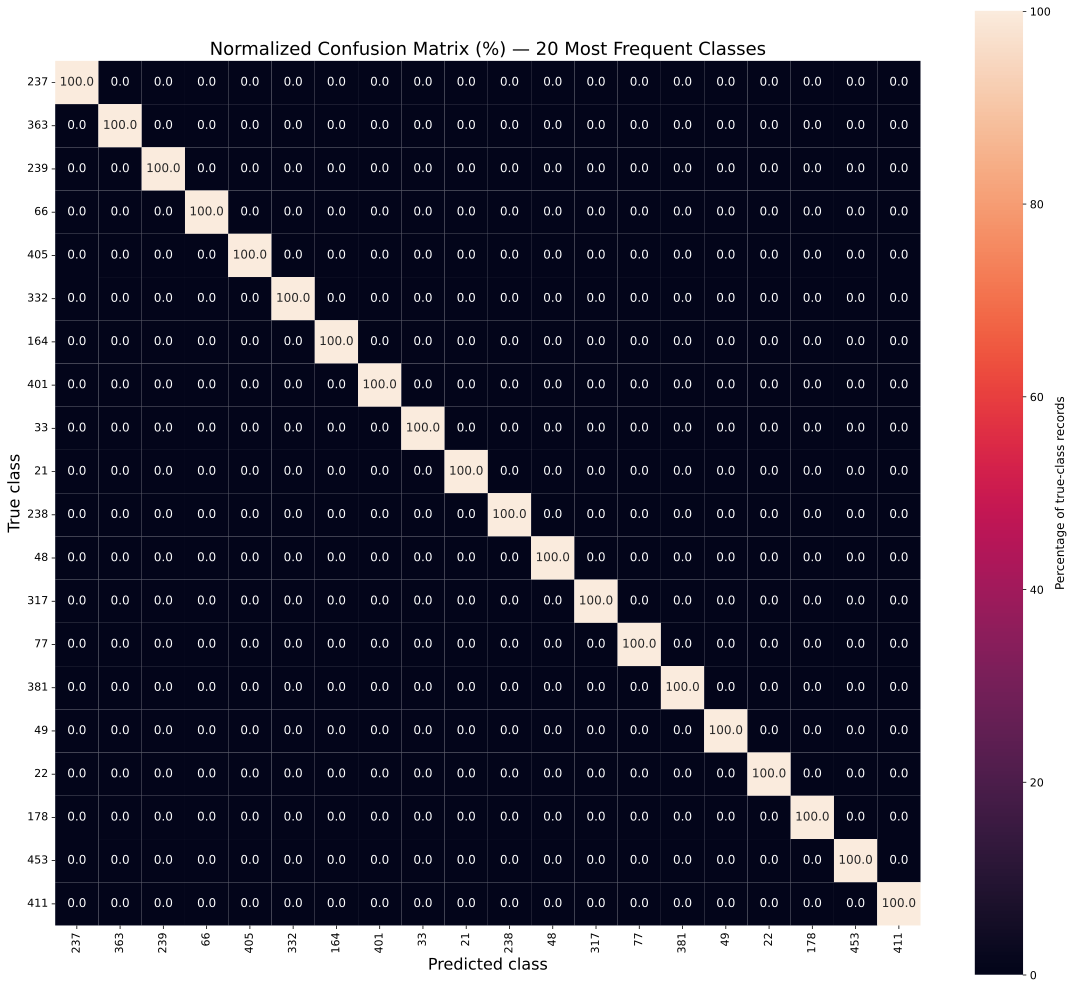

In [32]:
# --------------------------------------------------
# Normalized confusion matrix for the 20
# most frequent verbal-noun classes
# --------------------------------------------------

TOP_N = 20

pred_series = pd.Series(
    standard_predictions,
    index=y_test.index
)


# Most frequent true classes in the test set
top_classes = (
    y_test
    .value_counts()
    .head(TOP_N)
    .index
    .tolist()
)


# Keep test rows whose true class belongs to
# the selected set.
mask = y_test.isin(
    top_classes
)

y_test_selected = y_test[mask]
pred_selected = pred_series[mask]


cm_top = confusion_matrix(
    y_test_selected,
    pred_selected,
    labels=top_classes
)


# Row-wise normalization:
# each row represents 100% of one true class.
row_totals = cm_top.sum(
    axis=1,
    keepdims=True
)

cm_top_normalized = np.divide(
    cm_top,
    row_totals,
    out=np.zeros_like(
        cm_top,
        dtype=float
    ),
    where=row_totals != 0
)

cm_top_percent = (
    cm_top_normalized
    * 100
)


# --------------------------------------------------
# Plot
# --------------------------------------------------

fig, ax = plt.subplots(
    figsize=(16, 14)
)

sns.heatmap(
    cm_top_percent,
    annot=True,
    fmt=".1f",
    xticklabels=top_classes,
    yticklabels=top_classes,
    cbar=True,
    square=True,
    ax=ax,
    annot_kws={
        "size": 12
    }
)

ax.set_title(
    f"Normalized Confusion Matrix (%) — "
    f"{TOP_N} Most Frequent Classes",
    fontsize=18
)

ax.set_xlabel(
    "Predicted class",
    fontsize=16
)

ax.set_ylabel(
    "True class",
    fontsize=16
)

ax.tick_params(
    axis="x",
    labelrotation=90,
    labelsize=11
)

ax.tick_params(
    axis="y",
    labelrotation=0,
    labelsize=11
)


# Color-bar label size
colorbar = ax.collections[0].colorbar

if colorbar is not None:
    colorbar.ax.tick_params(
        labelsize=11
    )
    colorbar.set_label(
        "Percentage of true-class records",
        fontsize=12
    )


fig.tight_layout()


# --------------------------------------------------
# Save figure
# --------------------------------------------------

fig.savefig(
    FIGURES_DIR / "confusion_matrix_top20.pdf",
    bbox_inches="tight"
)

fig.savefig(
    FIGURES_DIR / "confusion_matrix_top20.svg",
    bbox_inches="tight"
)

fig.savefig(
    FIGURES_DIR / "confusion_matrix_top20.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

### Confusion matrix for frequent and lower-performing classes

The preceding visualization focuses on the most frequent classes and therefore mainly illustrates the model's behaviour on well-represented verbal nouns.

To inspect more difficult classes, the second matrix combines:

- the 10 most frequent classes in the test set; and
- classes whose F1-score is between 0.50 and 0.90.

The classes satisfying this criterion are determined automatically from the classification report generated by the current run and are printed by the code below.

This visualization complements the overall accuracy by showing where the remaining classification errors are concentrated.

Most frequent classes: [237, 363, 239, 66, 405, 332, 164, 401, 33, 21]
Classes with F1 between 0.50 and 0.90: [449, 24]
Selected classes: [237, 363, 239, 66, 405, 332, 164, 401, 33, 21, 449, 24]
Number of selected classes: 12


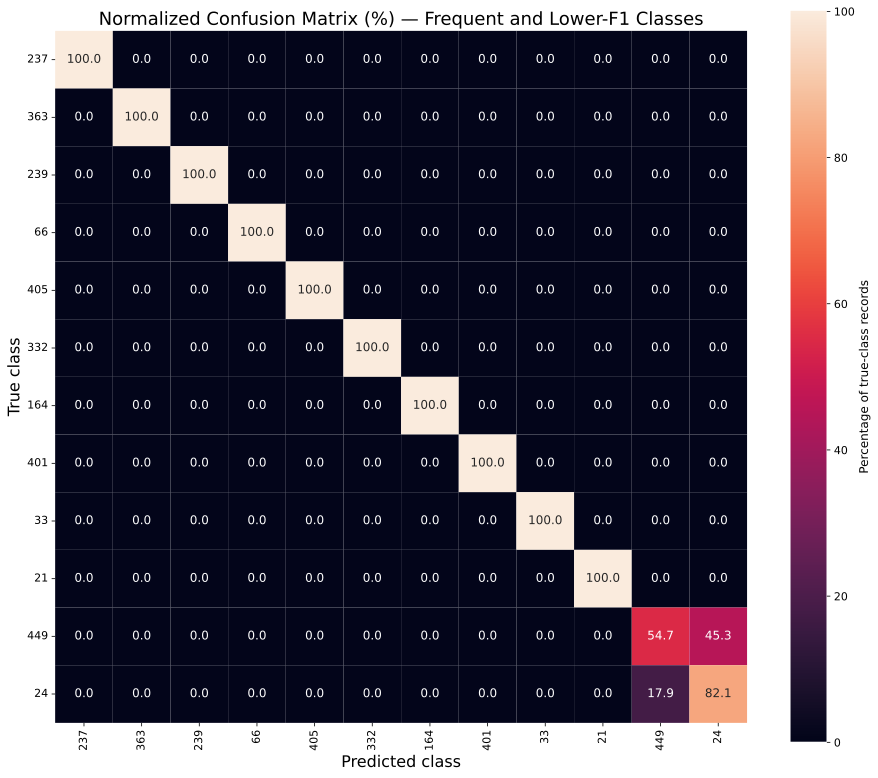

In [33]:
# --------------------------------------------------
# Normalized confusion matrix for:
#
#   - 10 most frequent classes
#   - classes with F1-score between 0.50 and 0.90
#
# This highlights both common classes and selected
# lower-performing classes.
# --------------------------------------------------

TOP_N = 10

LOWER_F1_MIN = 0.50
LOWER_F1_MAX = 0.90


# --------------------------------------------------
# Most frequent classes
# --------------------------------------------------

top_classes = (
    y_test
    .value_counts()
    .head(TOP_N)
    .index
    .tolist()
)


# --------------------------------------------------
# Select lower-performing classes
#
# class_report was created in the classification
# report cell above.
# --------------------------------------------------

lower_f1_classes = (
    class_report[
        (class_report["f1-score"] >= LOWER_F1_MIN)
        &
        (class_report["f1-score"] <= LOWER_F1_MAX)
    ]
    .sort_values(
        "f1-score"
    )
    .index
    .tolist()
)


# Combine both groups while preserving order
selected_classes = list(
    dict.fromkeys(
        top_classes
        + lower_f1_classes
    )
)


print(
    "Most frequent classes:",
    top_classes
)

print(
    "Classes with F1 between "
    f"{LOWER_F1_MIN:.2f} and "
    f"{LOWER_F1_MAX:.2f}:",
    lower_f1_classes
)

print(
    "Selected classes:",
    selected_classes
)

print(
    "Number of selected classes:",
    len(selected_classes)
)


# --------------------------------------------------
# Select relevant test records
# --------------------------------------------------

mask = y_test.isin(
    selected_classes
)

y_test_selected = y_test[mask]
pred_selected = pred_series[mask]


cm_selected = confusion_matrix(
    y_test_selected,
    pred_selected,
    labels=selected_classes
)


# --------------------------------------------------
# Row-wise normalization
# --------------------------------------------------

row_totals = cm_selected.sum(
    axis=1,
    keepdims=True
)

cm_selected_normalized = np.divide(
    cm_selected,
    row_totals,
    out=np.zeros_like(
        cm_selected,
        dtype=float
    ),
    where=row_totals != 0
)

cm_selected_percent = (
    cm_selected_normalized
    * 100
)


# --------------------------------------------------
# Plot
# --------------------------------------------------

fig, ax = plt.subplots(
    figsize=(13, 11)
)

sns.heatmap(
    cm_selected_percent,
    annot=True,
    fmt=".1f",
    xticklabels=selected_classes,
    yticklabels=selected_classes,
    cbar=True,
    square=True,
    ax=ax,
    annot_kws={
        "size": 12
    }
)


ax.set_title(
    "Normalized Confusion Matrix (%) — "
    "Frequent and Lower-F1 Classes",
    fontsize=18
)

ax.set_xlabel(
    "Predicted class",
    fontsize=16
)

ax.set_ylabel(
    "True class",
    fontsize=16
)


ax.tick_params(
    axis="x",
    labelrotation=90,
    labelsize=11
)

ax.tick_params(
    axis="y",
    labelrotation=0,
    labelsize=11
)


colorbar = ax.collections[0].colorbar

if colorbar is not None:
    colorbar.ax.tick_params(
        labelsize=11
    )
    colorbar.set_label(
        "Percentage of true-class records",
        fontsize=12
    )


fig.tight_layout()


# --------------------------------------------------
# Save figure
# --------------------------------------------------

fig.savefig(
    FIGURES_DIR
    / "confusion_matrix_frequent_and_lower_f1.pdf",
    bbox_inches="tight"
)

fig.savefig(
    FIGURES_DIR
    / "confusion_matrix_frequent_and_lower_f1.svg",
    bbox_inches="tight"
)

fig.savefig(
    FIGURES_DIR
    / "confusion_matrix_frequent_and_lower_f1.png",
    dpi=600,
    bbox_inches="tight"
)


plt.show()

## 12. Reconstruct missing verbal nouns

The file `data_vn-` contains records for which the verbal noun is not known.

This dataset is **not an evaluation dataset**, because no ground-truth
verbal noun is available.

Instead, the final Random Forest trained on all labelled data is applied to
these records in order to reconstruct the missing verbal-noun values.

Exactly the same preprocessing function and feature order used for model
training are applied to these records.

In [34]:
missing_vn_raw = pd.read_csv(
    MISSING_DATA_PATH,
    sep=";"
)


missing_columns = [
    column
    for column in REQUIRED_FEATURE_COLUMNS
    if column not in missing_vn_raw.columns
]


if missing_columns:
    raise ValueError(
        f"Required columns are missing from the prediction dataset: "
        f"{missing_columns}"
    )


print(
    "Records with missing verbal nouns:",
    len(missing_vn_raw)
)

display(
    missing_vn_raw.head()
)

Records with missing verbal nouns: 99999


,form,tense_in_paradigm,person,number,preverb,pre2,root,sf2,caus_sf,ending,tsch_class,morph_type,sub_id,id,vn
0,ვაამხანაგებ,present,1,sg,-,ვა,ამხანაგ,ებ,-,-,T1,active,39-8,39,-
1,აამხანაგებ,present,2,sg,-,ა,ამხანაგ,ებ,-,-,T1,active,39-8,39,-
2,აამხანაგებს,present,3,sg,-,ა,ამხანაგ,ებ,-,ს,T1,active,39-8,39,-
3,ვაამხანაგებთ,present,1,pl,-,ვა,ამხანაგ,ებ,-,თ,T1,active,39-8,39,-
4,აამხანაგებთ,present,2,pl,-,ა,ამხანაგ,ებ,-,თ,T1,active,39-8,39,-


In [35]:
print(
    "Categorical values occurring in prediction data "
    "but not in labelled training data:\n"
)


for column in CATEGORY_MAPPINGS:

    training_values = set(
        kv_raw[column]
        .astype(str)
        .unique()
    )

    prediction_values = set(
        missing_vn_raw[column]
        .astype(str)
        .unique()
    )

    unseen_values = sorted(
        prediction_values - training_values
    )

    if unseen_values:
        print(
            f"{column}: {unseen_values}"
        )

Categorical values occurring in prediction data but not in labelled training data:

preverb: ['ზეწამო', 'შთა', 'წინააღ']


In [36]:
X_missing, missing_raw_sub_id = preprocess_features(
    missing_vn_raw
)


# --------------------------------------------------
# Verify compatibility with the training matrix
# --------------------------------------------------

if list(X_missing.columns) != MODEL_FEATURES:
    raise ValueError(
        "Prediction feature order does not match the training "
        "feature order."
    )


if X_missing.isna().sum().sum() != 0:
    raise ValueError(
        "The prepared prediction matrix contains missing values."
    )


print(
    "Prediction matrix shape:",
    X_missing.shape
)

print(
    "Feature order:"
)

print(
    list(X_missing.columns)
)

display(
    X_missing.head()
)

Prediction matrix shape: (99999, 14)
Feature order:
['formd', 'tense', 'person', 'number', 'preverb', 'pre2d', 'rootd', 'sf2', 'caus_sf', 'endingd', 'tsch_class', 'morph_type', 'sub_id', 'id']


,formd,tense,person,number,preverb,pre2d,rootd,sf2,caus_sf,endingd,tsch_class,morph_type,sub_id,id
0,1649,1,1,1,0,293,1063,4,0,48,21,1,8,39
1,1500,1,2,1,0,144,1063,4,0,48,21,1,8,39
2,1661,1,3,1,0,144,1063,4,0,161,21,1,8,39
3,1800,1,1,2,0,293,1063,4,0,151,21,1,8,39
4,1651,1,2,2,0,144,1063,4,0,151,21,1,8,39


In [37]:
predicted_class_ids = final_model.predict(
    X_missing
)


predicted_verbal_nouns = [
    index_vn_rev[int(class_id)]
    for class_id in predicted_class_ids
]


solution = missing_vn_raw.copy()

solution["vn"] = predicted_verbal_nouns


OUTPUT_FILE = (
    RESULTS_DIR
    / "predicted_missing_verbal_nouns.csv"
)


solution.to_csv(
    OUTPUT_FILE,
    sep=";",
    index=False,
    encoding="utf-8"
)


print(
    "Number of predicted verbal nouns:",
    len(solution)
)

print(
    "Saved predictions to:",
    OUTPUT_FILE
)


display(
    solution.head()
)

Number of predicted verbal nouns: 99999
Saved predictions to: results/predicted_missing_verbal_nouns.csv


,form,tense_in_paradigm,person,number,preverb,pre2,root,sf2,caus_sf,ending,tsch_class,morph_type,sub_id,id,vn
0,ვაამხანაგებ,present,1,sg,-,ვა,ამხანაგ,ებ,-,-,T1,active,39-8,39,*ამხანაგება
1,აამხანაგებ,present,2,sg,-,ა,ამხანაგ,ებ,-,-,T1,active,39-8,39,*ამხანაგება
2,აამხანაგებს,present,3,sg,-,ა,ამხანაგ,ებ,-,ს,T1,active,39-8,39,*ამხანაგება
3,ვაამხანაგებთ,present,1,pl,-,ვა,ამხანაგ,ებ,-,თ,T1,active,39-8,39,*ამხანაგება
4,აამხანაგებთ,present,2,pl,-,ა,ამხანაგ,ებ,-,თ,T1,active,39-8,39,*ამხანაგება


In [38]:
summary_top_features = (
    importance_df
    .head(3)
)

summary_top_features_text = ", ".join(
    f"`{row.feature}` ({row.importance_percent:.2f}%)"
    for row in summary_top_features.itertuples()
)

display(Markdown(f"""
# Summary

This notebook implements the complete Random Forest-based data-completion workflow used in **KartuVerbs 2.2**.

The principal results calculated by the current run are:

- standard 80/20 row-level test accuracy: **{pct(test_accuracy)}**;
- OOB accuracy: **{pct(oob_accuracy)}**;
- five-fold KFold mean accuracy: **{pct(kf_results_df["test_accuracy"].mean())} ± {pp(kf_results_df["test_accuracy"].std(), 3)}**;
- GroupShuffleSplit accuracy with complete `raw_sub_id` groups separated: **{pct(gss_test_accuracy)}**;
- five-fold GroupKFold mean accuracy: **{pct(group_kfold_results_df["test_accuracy"].mean())} ± {pp(group_kfold_results_df["test_accuracy"].std())}**;
- number of verbal-noun target classes: **{nfmt(len(class_report))}**;
- number of missing verbal-noun records reconstructed by the final model: **{nfmt(len(solution))}**.

The three highest impurity-based feature importances in the complete model are {summary_top_features_text}.

The ablation experiments show:

- without `id`: standard accuracy **{pct(test_accuracy_no_id)}**, GroupKFold **{pct(group_kfold_mean_no_id)}**;
- without `sub_id`: standard accuracy **{pct(test_accuracy_no_sub_id)}**, GroupKFold **{pct(group_kfold_mean_no_sub_id)}**;
- without both `id` and `sub_id`: standard accuracy **{pct(test_accuracy_no_ids)}**, GroupKFold **{pct(group_kfold_mean_no_ids)}**.

These results clarify the intended role of the model.

The Random Forest is primarily a **data-completion model for an existing lexicographic and morphological resource**. It is particularly effective when the resource already contains related lexical and paradigmatic structures. It should not be interpreted as a general-purpose generator of verbal nouns for arbitrary unseen Georgian verbs.

The ablation experiments further show that part of the complete model's predictive strength derives from structural information encoded by identifier-related variables. High predictive agreement with the existing dataset therefore does not by itself establish linguistic correctness or naturalness.

The automatically reconstructed values are not considered definitive linguistic ground truth. Additional evidence is obtained through comparison with the Georgian National Corpus, while complementary expert linguistic validation is planned through the new Headwork crowdsourcing task.

## Reproducibility outputs

Running this notebook creates:

- `results/evaluation_summary.csv`
- `results/classification_report_standard_split.csv`
- `results/kfold_results.csv`
- `results/group_kfold_results.csv`
- `results/feature_importance.csv`
- `results/ablation_without_id.csv`
- `results/ablation_without_sub_id.csv`
- `results/ablation_without_id_and_sub_id.csv`
- `results/verbal_noun_class_mapping.json`
- `results/predicted_missing_verbal_nouns.csv`
- `figures/random_forest_feature_importance.pdf`
- `figures/random_forest_feature_importance.svg`
- `figures/random_forest_feature_importance.png`
- `figures/confusion_matrix_frequent_and_lower_f1.pdf`
- `figures/confusion_matrix_frequent_and_lower_f1.svg`
- `figures/confusion_matrix_frequent_and_lower_f1.png`
- `figures/confusion_matrix_top20.pdf`
- `figures/confusion_matrix_top20.svg`
- `figures/confusion_matrix_top20.png`
- `models/kartuverbs_random_forest.joblib`
- `models/kartuverbs_model_metadata.json`

These files document the evaluation results, ablation experiments, feature encoding, trained model, target-class mapping, and reconstructed verbal nouns required to reproduce the machine-learning component of KartuVerbs.
"""))


# Summary

This notebook implements the complete Random Forest-based data-completion workflow used in **KartuVerbs 2.2**.

The principal results calculated by the current run are:

- standard 80/20 row-level test accuracy: **99.91%**;
- OOB accuracy: **99.91%**;
- five-fold KFold mean accuracy: **99.92% ± 0.019 pp**;
- GroupShuffleSplit accuracy with complete `raw_sub_id` groups separated: **65.34%**;
- five-fold GroupKFold mean accuracy: **67.59% ± 2.03 pp**;
- number of verbal-noun target classes: **493**;
- number of missing verbal-noun records reconstructed by the final model: **99,999**.

The three highest impurity-based feature importances in the complete model are `id` (28.81%), `rootd` (26.08%), `sub_id` (16.54%).

The ablation experiments show:

- without `id`: standard accuracy **97.89%**, GroupKFold **46.25%**;
- without `sub_id`: standard accuracy **98.50%**, GroupKFold **68.42%**;
- without both `id` and `sub_id`: standard accuracy **85.73%**, GroupKFold **45.18%**.

These results clarify the intended role of the model.

The Random Forest is primarily a **data-completion model for an existing lexicographic and morphological resource**. It is particularly effective when the resource already contains related lexical and paradigmatic structures. It should not be interpreted as a general-purpose generator of verbal nouns for arbitrary unseen Georgian verbs.

The ablation experiments further show that part of the complete model's predictive strength derives from structural information encoded by identifier-related variables. High predictive agreement with the existing dataset therefore does not by itself establish linguistic correctness or naturalness.

The automatically reconstructed values are not considered definitive linguistic ground truth. Additional evidence is obtained through comparison with the Georgian National Corpus, while complementary expert linguistic validation is planned through the new Headwork crowdsourcing task.

## Reproducibility outputs

Running this notebook creates:

- `results/evaluation_summary.csv`
- `results/classification_report_standard_split.csv`
- `results/kfold_results.csv`
- `results/group_kfold_results.csv`
- `results/feature_importance.csv`
- `results/ablation_without_id.csv`
- `results/ablation_without_sub_id.csv`
- `results/ablation_without_id_and_sub_id.csv`
- `results/verbal_noun_class_mapping.json`
- `results/predicted_missing_verbal_nouns.csv`
- `figures/random_forest_feature_importance.pdf`
- `figures/random_forest_feature_importance.svg`
- `figures/random_forest_feature_importance.png`
- `figures/confusion_matrix_frequent_and_lower_f1.pdf`
- `figures/confusion_matrix_frequent_and_lower_f1.svg`
- `figures/confusion_matrix_frequent_and_lower_f1.png`
- `figures/confusion_matrix_top20.pdf`
- `figures/confusion_matrix_top20.svg`
- `figures/confusion_matrix_top20.png`
- `models/kartuverbs_random_forest.joblib`
- `models/kartuverbs_model_metadata.json`

These files document the evaluation results, ablation experiments, feature encoding, trained model, target-class mapping, and reconstructed verbal nouns required to reproduce the machine-learning component of KartuVerbs.


In [39]:
elapsed_seconds = perf_counter() - NOTEBOOK_START_TIME

hours, remainder = divmod(elapsed_seconds, 3600)
minutes, seconds = divmod(remainder, 60)

print(
    f"Total notebook execution time: "
    f"{int(hours):02d}:{int(minutes):02d}:{seconds:05.2f}"
)

Total notebook execution time: 00:27:06.19
